##Connect to Google Drive

In [ ]:
from __future__ import annotations
import csv
import re
import sys
import time
from collections import defaultdict
from pathlib import Path
from urllib.parse import urljoin, urlparse

import pandas as pd
import requests
from bs4 import BeautifulSoup

In [ ]:
BASE = "https://hoopsprospects.com"
SCOUTING_INDEX = "https://hoopsprospects.com/scouting-reports/"
DRAFT_BOARD_URLS = [
    "https://hoopsprospects.com/nba-draft-board/",
    "https://hoopsprospects.com/nba-draft-board/2024-nba-draft-board/",
    "https://hoopsprospects.com/nba-draft-board/2024-nba-draft-board/2023-nba-draft-board/",
    "https://hoopsprospects.com/nba-draft-board/2024-nba-draft-board/2022-nba-draft-board-2/",
    "https://hoopsprospects.com/nba-draft-board/2024-nba-draft-board/2021-draft-board/",
    "https://hoopsprospects.com/nba-draft-board/2024-nba-draft-board/2020-draft-board/",
    "https://hoopsprospects.com/nba-draft-board/2024-nba-draft-board/2019-draft-board/",
    "https://hoopsprospects.com/nba-draft-board/2024-nba-draft-board/2017-2018-draft-board/",
    "https://hoopsprospects.com/nba-draft-board/2024-nba-draft-board/2017-draft-board/",
]
HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; HoopsProspectsScraper/1.0; +https://openai.com)"
}
SESSION = requests.Session()
SESSION.headers.update(HEADERS)


In [ ]:
def fetch(url: str) -> BeautifulSoup:
    for i in range(4):
        try:
            r = SESSION.get(url, timeout=40)
            r.raise_for_status()
            return BeautifulSoup(r.text, "lxml")
        except Exception:
            if i == 3:
                raise
            time.sleep(1.5 * (i + 1))
    raise RuntimeError(f"failed to fetch {url}")

In [ ]:
def clean_text(s: str) -> str:
    s = s.replace("\xa0", " ")
    s = re.sub(r"\s+", " ", s)
    return s.strip()

In [ ]:
def slugify_name(name: str) -> str:
    slug = name.lower()
    slug = slug.replace(".", "")
    slug = slug.replace("'", "")
    slug = slug.replace("’", "")
    slug = slug.replace("/", "-")
    slug = re.sub(r"[^a-z0-9]+", "-", slug)
    slug = re.sub(r"-+", "-", slug).strip("-")
    return slug

In [ ]:
def parse_scouting_index() -> list[dict]:
    soup = fetch(SCOUTING_INDEX)
    rows = []
    # Try HTML table first
    table = soup.find("table")
    if table:
        trs = table.find_all("tr")
        for tr in trs[1:]:
            cells = tr.find_all(["td", "th"])
            if len(cells) < 5:
                continue
            first = clean_text(cells[0].get_text(" ", strip=True))
            last = clean_text(cells[1].get_text(" ", strip=True))
            team = clean_text(cells[2].get_text(" ", strip=True))
            draft_year = clean_text(cells[3].get_text(" ", strip=True))
            a = cells[4].find("a", href=True)
            report_text = clean_text(cells[4].get_text(" ", strip=True))
            report_url = urljoin(BASE, a["href"]) if a else ""
            rows.append(
                {
                    "player_name": clean_text(f"{first} {last}"),
                    "team_school": team,
                    "draft_year": draft_year,
                    "report_label": report_text,
                    "report_url": report_url,
                }
            )
    if not rows:
        # Fallback: regex from full page text
        text = soup.get_text("\n")
        pattern = re.compile(r"^([A-Za-z\.'\-]+)\s+([A-Za-z\.'\-]+)\s+(.+?)\s+(\d{4})\s+((?:\d{4}\.\d{2}\.\d{2})|(?:\d{4}\.Mock\.[Rr]\d))$", re.M)
        for m in pattern.finditer(text):
            rows.append({
                "player_name": clean_text(m.group(1) + " " + m.group(2)),
                "team_school": clean_text(m.group(3)),
                "draft_year": m.group(4),
                "report_label": m.group(5),
                "report_url": "",
            })

    # filter mock-draft entries
    filtered = []
    for row in rows:
        lbl = row["report_label"].lower()
        url = row["report_url"].lower()
        if "mock" in lbl or "mock" in url:
            continue
        filtered.append(row)

    # If the site table provides missing direct URLs, infer likely single-player URL
    for row in filtered:
        if not row["report_url"]:
            date_text = row["report_label"]
            m = re.match(r"(\d{4})\.(\d{2})\.(\d{2})", date_text)
            if m:
                y, mo, _ = m.groups()
                row["report_url"] = f"{BASE}/{y}/{mo}/{slugify_name(row['player_name'])}-scouting-report/"
    return filtered

In [ ]:
def extract_meta_text(soup: BeautifulSoup) -> str:
    text = soup.get_text("\n", strip=True)
    text = text.replace("\xa0", " ")
    return text

In [ ]:
FIELD_PATTERNS = {
    "position": r"Position:\s*([^\n]+?)\s+(?:Team/Class:|Team/Class\s*:)",
    "team_class": r"Team/Class:\s*([^\n]+?)\s+(?:Birthday:|Birthday\s*:)",
    "birthday": r"Birthday:\s*([^\n]+?)\s+(?:Nationality:|Nationality\s*:)",
    "nationality": r"Nationality:\s*([^\n]+?)\s+(?:Height:|Height\s*:)",
    "height": r"Height:\s*([^\n]+?)\s+(?:Weight:|Weight\s*:)",
    "weight": r"Weight:\s*([^\n]+?)\s+(?:Wingspan:|Wingspan\s*:)",
    "wingspan": r"Wingspan:\s*([^\n]*?)\s+(?:Vertical:|Vertical\s*:)",
    "vertical": r"Vertical:\s*([^\n]*?)\s+(?:Dom Hand:|Shot Hand:|Stats:)",
    "hand": r"(?:Dom Hand|Shot Hand):\s*([^\n]+?)\s+Stats:",
}

In [ ]:
def parse_single_player_report(url: str, player_name: str, draft_year: str, team_school: str, report_label: str) -> dict:
    soup = fetch(url)
    title = clean_text(soup.find("h1").get_text(" ", strip=True)) if soup.find("h1") else f"{player_name} Scouting Report"
    text = extract_meta_text(soup)
    date_iso = None
    mdate = re.search(r"(January|February|March|April|May|June|July|August|September|October|November|December)\s+(\d{1,2}),\s+(\d{4})", text)
    if mdate:
        months = {m:i for i,m in enumerate(["January","February","March","April","May","June","July","August","September","October","November","December"],1)}
        date_iso = f"{mdate.group(3)}-{months[mdate.group(1)]:02d}-{int(mdate.group(2)):02d}"
    data = {
        "player_name": player_name,
        "report_year": draft_year,
        "team_school": team_school,
        "report_label": report_label,
        "report_date": date_iso or report_label.replace(".", "-"),
        "report_title": title,
        "position": "",
        "team_class": "",
        "birthday": "",
        "nationality": "",
        "height": "",
        "weight": "",
        "wingspan": "",
        "vertical": "",
        "hand": "",
        "stats_url": "",
        "report_url": url,
        "details_text": "",
    }
    for field, pat in FIELD_PATTERNS.items():
        m = re.search(pat, text, flags=re.I | re.S)
        if m:
            data[field] = clean_text(m.group(1))
    # stats url
    a = soup.find("a", string=re.compile("Click here", re.I))
    if a and a.get("href"):
        data["stats_url"] = urljoin(url, a["href"])
    # gather body paragraphs
    article = soup.find("article") or soup
    paras = []
    for p in article.find_all(["p", "li"]):
        t = clean_text(p.get_text(" ", strip=True))
        if not t:
            continue
        if t.lower().startswith(("share this", "like this", "leave a reply", "follow us", "copyright")):
            continue
        if "click to share on" in t.lower():
            continue
        if t == title:
            continue
        paras.append(t)
    # remove obvious header/meta duplicates
    paras = [p for p in paras if p not in {player_name, title}]
    # drop lead metadata-like short strings
    filtered = []
    for p in paras:
        if len(p) < 8:
            continue
        if re.match(r"^(position|birthday|nationality|height|weight|wingspan|vertical|dom hand|shot hand|stats):", p, re.I):
            continue
        filtered.append(p)
    data["details_text"] = " ".join(filtered[:40]).strip()
    return data

In [ ]:
def extract_section_from_group_page(soup: BeautifulSoup, player_name: str) -> tuple[dict, str] | tuple[None, None]:
    # 1) prefer a "Read more" link to a dedicated report
    name_parts = [re.escape(p) for p in player_name.split()]
    pattern = re.compile(rf"{name_parts[0]}.*{name_parts[-1]}.*Scouting Report", re.I)
    for a in soup.find_all("a", href=True):
        txt = clean_text(a.get_text(" ", strip=True))
        href = urljoin(BASE, a["href"])
        if pattern.search(txt) and "mock" not in href.lower():
            return None, href
    # 2) otherwise extract section text from group article text
    text = extract_meta_text(soup)
    lines = [clean_text(x) for x in text.splitlines()]
    indices = [i for i, line in enumerate(lines) if player_name.lower() in line.lower()]
    if not indices:
        return None, None
    start = indices[0]
    end = len(lines)
    for i in range(start + 1, len(lines)):
        if re.match(r"^\d+\.\s+[A-Z]", lines[i]) or (lines[i].startswith("Player") and i > start + 3):
            end = i
            break
    section = " ".join(lines[start:end])
    return {"details_text": section}, None


In [ ]:
def parse_group_or_fallback(url: str, player_name: str, draft_year: str, team_school: str, report_label: str) -> dict:
    soup = fetch(url)
    # Try to jump to dedicated single-player page if linked
    section, dedicated = extract_section_from_group_page(soup, player_name)
    if dedicated:
        try:
            return parse_single_player_report(dedicated, player_name, draft_year, team_school, report_label)
        except Exception:
            pass
    title = clean_text(soup.find("h1").get_text(" ", strip=True)) if soup.find("h1") else ""
    out = {
        "player_name": player_name,
        "report_year": draft_year,
        "team_school": team_school,
        "report_label": report_label,
        "report_date": report_label.replace(".", "-"),
        "report_title": title,
        "position": "",
        "team_class": "",
        "birthday": "",
        "nationality": "",
        "height": "",
        "weight": "",
        "wingspan": "",
        "vertical": "",
        "hand": "",
        "stats_url": "",
        "report_url": url,
        "details_text": section["details_text"] if section else "",
    }
    return out

In [ ]:
def parse_all_scouting(out_dir: Path) -> pd.DataFrame:
    index_rows = parse_scouting_index()
    results = []
    for i, row in enumerate(index_rows, 1):
        url = row["report_url"]
        try:
            if re.search(r"/[a-z0-9\-]+-scouting-report/?$", url):
                results.append(parse_single_player_report(url, row["player_name"], row["draft_year"], row["team_school"], row["report_label"]))
            else:
                results.append(parse_group_or_fallback(url, row["player_name"], row["draft_year"], row["team_school"], row["report_label"]))
        except Exception as e:
            results.append({
                "player_name": row["player_name"],
                "report_year": row["draft_year"],
                "team_school": row["team_school"],
                "report_label": row["report_label"],
                "report_date": row["report_label"].replace(".", "-"),
                "report_title": "",
                "position": "",
                "team_class": "",
                "birthday": "",
                "nationality": "",
                "height": "",
                "weight": "",
                "wingspan": "",
                "vertical": "",
                "hand": "",
                "stats_url": "",
                "report_url": url,
                "details_text": "",
                "error": str(e),
            })
        if i % 10 == 0:
            print(f"[scouting] processed {i}/{len(index_rows)}", file=sys.stderr)
        time.sleep(0.25)
    df = pd.DataFrame(results)
    df.to_csv(out_dir / "scouting_reports_master.csv", index=False)
    for year, g in df.groupby("report_year"):
        safe = str(year).replace("/", "_")
        g.to_csv(out_dir / f"scouting_reports_{safe}.csv", index=False)
    return df

In [ ]:
def infer_board_year(url: str, soup: BeautifulSoup) -> str:
    h1 = soup.find("h1")
    title = clean_text(h1.get_text(" ", strip=True)) if h1 else ""
    m = re.search(r"(20\d{2})(?:\s*[-/]\s*(20\d{2}))?\s+NBA Draft Board", title, re.I)
    if m:
        if m.group(2):
            return f"{m.group(1)}-{m.group(2)}"
        return m.group(1)
    for cand in ["2025","2024","2023","2022","2021","2020","2019","2018","2017"]:
        if cand in url:
            return cand
    return "unknown"

In [ ]:
def parse_draft_board(url: str) -> pd.DataFrame:
    # read_html usually works well for these sortable tables
    try:
        tables = pd.read_html(url)
    except Exception:
        tables = []
    table = None
    for t in tables:
        cols = [str(c).strip().lower() for c in t.columns]
        if "rank" in cols or "#player" in cols or "player" in cols:
            table = t.copy()
            break
    soup = fetch(url)
    year = infer_board_year(url, soup)
    if table is None:
        # fallback: regex line parsing
        text = extract_meta_text(soup)
        rows = []
        for line in text.splitlines():
            line = clean_text(line)
            m = re.match(r"^(\d+)\s+(.+)$", line)
            if not m:
                continue
            rank = int(m.group(1))
            # rough player parse: rank + player name before position token
            tokens = m.group(2).split()
            if len(tokens) < 2:
                continue
            # stop name before known positions
            pos_tokens = {"PG","SG","SF","PF","C","CG","W","F"}
            name_parts = []
            for tok in tokens:
                if tok in pos_tokens:
                    break
                name_parts.append(tok)
            if not name_parts:
                continue
            rows.append({"board_year": year, "ranking": rank, "player_name": " ".join(name_parts), "source_url": url})
        return pd.DataFrame(rows)

    cols = {str(c).strip().lower(): c for c in table.columns}
    rank_col = cols.get("rank") or list(table.columns)[0]
    player_col = cols.get("player") or cols.get("#player")
    if player_col is None:
        # sometimes first two columns are rank/player
        player_col = list(table.columns)[1]
    out = pd.DataFrame({
        "board_year": year,
        "ranking": table[rank_col],
        "player_name": table[player_col],
        "source_url": url,
    })
    out["ranking"] = pd.to_numeric(out["ranking"], errors="coerce")
    out = out.dropna(subset=["ranking", "player_name"])
    out["ranking"] = out["ranking"].astype(int)
    out["player_name"] = out["player_name"].astype(str).map(clean_text)
    return out

In [ ]:
def parse_all_draft_boards(out_dir: Path) -> pd.DataFrame:
    frames = []
    for url in DRAFT_BOARD_URLS:
        try:
            df = parse_draft_board(url)
            frames.append(df)
            print(f"[boards] parsed {url} -> {len(df)} rows", file=sys.stderr)
            time.sleep(0.25)
        except Exception as e:
            print(f"[boards] failed {url}: {e}", file=sys.stderr)
    if not frames:
        raise RuntimeError("no draft boards parsed")
    master = pd.concat(frames, ignore_index=True)
    master.to_csv(out_dir / "draft_board_rankings_master.csv", index=False)
    for year, g in master.groupby("board_year"):
        safe = str(year).replace("/", "_")
        g.to_csv(out_dir / f"draft_board_{safe}.csv", index=False)
    return master


In [ ]:
def main():
    out_dir = Path(sys.argv[1]) if len(sys.argv) > 1 else Path.cwd() / "hoopsprospects_output"
    out_dir.mkdir(parents=True, exist_ok=True)
    scouting = parse_all_scouting(out_dir)
    boards = parse_all_draft_boards(out_dir)
    print(f"Wrote {len(scouting)} scouting rows and {len(boards)} ranking rows to {out_dir}")

if __name__ == "__main__":
    main()

[scouting] processed 10/163
[scouting] processed 20/163
[scouting] processed 30/163
[scouting] processed 40/163
[scouting] processed 50/163
[scouting] processed 60/163
[scouting] processed 70/163
[scouting] processed 80/163
[scouting] processed 90/163
[scouting] processed 100/163
[scouting] processed 110/163
[scouting] processed 120/163
[scouting] processed 130/163
[scouting] processed 140/163
[scouting] processed 150/163
[scouting] processed 160/163
[boards] parsed https://hoopsprospects.com/nba-draft-board/ -> 200 rows
[boards] parsed https://hoopsprospects.com/nba-draft-board/2024-nba-draft-board/ -> 200 rows
[boards] parsed https://hoopsprospects.com/nba-draft-board/2024-nba-draft-board/2023-nba-draft-board/ -> 200 rows
[boards] parsed https://hoopsprospects.com/nba-draft-board/2024-nba-draft-board/2022-nba-draft-board-2/ -> 200 rows
[boards] parsed https://hoopsprospects.com/nba-draft-board/2024-nba-draft-board/2021-draft-board/ -> 200 rows
[boards] parsed https://hoopsprospects.c

Wrote 163 scouting rows and 1566 ranking rows to -f


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load the data (Note: Make sure to add NLP Final Project folder to MyDrive)

In [ ]:
BASE_PATH      = "/content/drive/MyDrive/NLP Final Project"
SCOUTS_PATH    = f"{BASE_PATH}/hoopsprospects_output/Edited scouting_reports_master.csv"
DRAFTS_PATH    = f"{BASE_PATH}/nba_drafts"

import pandas as pd

scouting_reports = pd.read_csv(SCOUTS_PATH)
print("Scouting reports shape:", scouting_reports.shape)
#print(scouting_reports.head(3))

draft_dataframes = []
for year in range(2018, 2026):
    path = f"{DRAFTS_PATH}/nba_draft_{year}.csv"
    df = pd.read_csv(path)
    df['draft_year'] = year
    draft_dataframes.append(df)

# Stack all drafts into one dataframe
all_drafts = pd.concat(draft_dataframes, ignore_index=True)
print("All drafts shape:", all_drafts.shape)
print("Columns:", all_drafts.columns.tolist())
all_drafts.head(3)


Scouting reports shape: (240, 18)
All drafts shape: (473, 8)
Columns: ['PLAYER', 'TEAM', 'AFFILIATION', 'YEAR', 'ROUND\nNUMBER', 'ROUND\nPICK', 'OVERALL\nPICK', 'draft_year']


,PLAYER,TEAM,AFFILIATION,YEAR,ROUND\nNUMBER,ROUND\nPICK,OVERALL\nPICK,draft_year
0,DEANDRE AYTON,Phoenix Suns,Arizona,2018,1,1,1,2018
1,MARVIN BAGLEY III,Sacramento Kings,Duke,2018,1,2,2,2018
2,LUKA DONČIĆ,Atlanta Hawks,Real Madrid Baloncesto (Spain),2018,1,3,3,2018


In [ ]:
import re

DRAFT_NAME_COL = 'PLAYER'
DRAFT_PICK_COL = 'OVERALL\nPICK'

# Normalize names to improve matching
def normalize_name(name):
    name = str(name).lower().strip()
    name = re.sub(r'\s+jr\.?$', '', name)
    name = re.sub(r'\s+sr\.?$', '', name)
    name = re.sub(r'\s+iii?$', '', name)
    name = re.sub(r'[^\w\s]', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    return name

scouting_reports['name_key'] = scouting_reports['player_name'].apply(normalize_name)
all_drafts['name_key'] = all_drafts[DRAFT_NAME_COL].apply(normalize_name)

# Merge
drafted = all_drafts[['name_key', DRAFT_PICK_COL]].copy()
drafted.columns = ['name_key', 'pick']

merged = scouting_reports.merge(drafted, on='name_key', how='left')
merged['pick']    = merged['pick'].fillna(0).astype(int)
merged['drafted'] = (merged['pick'] > 0).astype(int)

print("Merged shape:", merged.shape)
print("\nDrafted vs Undrafted:")
print(merged['drafted'].value_counts())

# Check who got marked undrafted
print("\nPlayers marked as undrafted:")
for name in sorted(merged[merged['drafted'] == 0]['player_name'].tolist()):
    print(" ", name)


Merged shape: (240, 21)

Drafted vs Undrafted:
drafted
1    187
0     53
Name: count, dtype: int64

Players marked as undrafted:
  Aaron Henry
  Allonzo Trier
  Aric Holman
  Bonzie Colson
  Brandon McCoy
  Caleb Martin
  Dean Wade
  Dedric Lawson
  Devon Dotson
  Eli John Ndiayne
  Hugo Gonzalez
  Ilias Kamardine
  Isaac Haas
  Jalen Lecque
  James Palmer
  Jared Harper
  Jared Rhoden
  Jayvon Graves
  Jeffrey Carroll
  Joao Vitor Franca
  Jonah Radebaugh
  Jontay Porter
  Josh Primo
  Joshua Obiesie
  Julian Champagnie
  Killian Tillie
  Kylor Kelley
  Lesley Varner
  Lonnie Walker
  Louis King
  Luguentz Dort
  Luka Doncic
  Malik Newman
  Marcos Louzada Silva
  Mohamed Bamba
  Naz Reid
  Nicolas Claxton
  Orlando Robinson
  R. J. Barrett
  Rawle Alkins
  Raymond Spalding
  Shamorie Ponds
  Stanley Umude
  Sviatoslav Mykhailiuk
  Terence Davis
  Trent Forrest
  Trevon Duval
  Tyler Hagedorn
  Tyson Ward
  Vince Edwards
  Vit Krejci
  Vrenz Bleijenbergh
  Yovel Zoosman


## Make manual fixes for players that were incorrectly marked as undrafted

In [ ]:
# check list of undrafted players from above and make manual fixes for incorrect results
manual_fixes = {
    'r j barrett':           'rj barrett',
    'lonnie walker':         'lonnie walker iv',
    'mohamed bamba':         'mo bamba',
    'sviatoslav mykhailiuk': 'svi mykhailiuk',
    'marcos louzada silva':  'didi louzada',
    'nicolas claxton':       'nic claxton',
    'josh primo':            'joshua primo',
    'luka dončić':           'luka doncic',
    'vít krejčí':            'vit krejci',
    'ray spalding':          'raymond spalding',
}

def normalize_name(name):
    name = str(name).lower().strip()
    name = re.sub(r'\s+jr\.?$', '', name)
    name = re.sub(r'\s+sr\.?$', '', name)
    name = re.sub(r'\s+iii?$', '', name)
    name = re.sub(r'[^\w\s]', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    return manual_fixes.get(name, name)

# Re-apply normalization to both dataframes
scouting_reports['name_key'] = scouting_reports['player_name'].apply(normalize_name)
all_drafts['name_key']       = all_drafts[DRAFT_NAME_COL].apply(normalize_name)

# Re-run merge
drafted = all_drafts[['name_key', DRAFT_PICK_COL]].copy()
drafted.columns = ['name_key', 'pick']

merged = scouting_reports.merge(drafted, on='name_key', how='left')
merged['pick']    = merged['pick'].fillna(0).astype(int)
merged['drafted'] = (merged['pick'] > 0).astype(int)

print("Drafted vs Undrafted:")
print(merged['drafted'].value_counts())

print("\nPlayers still marked as undrafted:")
for name in sorted(merged[merged['drafted'] == 0]['player_name'].tolist()):
    print(" ", name)

Drafted vs Undrafted:
drafted
1    197
0     43
Name: count, dtype: int64

Players still marked as undrafted:
  Aaron Henry
  Allonzo Trier
  Aric Holman
  Bonzie Colson
  Brandon McCoy
  Caleb Martin
  Dean Wade
  Dedric Lawson
  Devon Dotson
  Eli John Ndiayne
  Hugo Gonzalez
  Ilias Kamardine
  Isaac Haas
  Jalen Lecque
  James Palmer
  Jared Harper
  Jared Rhoden
  Jayvon Graves
  Jeffrey Carroll
  Joao Vitor Franca
  Jonah Radebaugh
  Jontay Porter
  Joshua Obiesie
  Julian Champagnie
  Killian Tillie
  Kylor Kelley
  Lesley Varner
  Louis King
  Luguentz Dort
  Malik Newman
  Naz Reid
  Orlando Robinson
  Rawle Alkins
  Shamorie Ponds
  Stanley Umude
  Terence Davis
  Trent Forrest
  Trevon Duval
  Tyler Hagedorn
  Tyson Ward
  Vince Edwards
  Vrenz Bleijenbergh
  Yovel Zoosman


## Make 80/20 train/test split for the four tasks

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

X = merged['details_text'].values

# Task 1: Undrafted vs. Drafted
y_task1 = merged['drafted'].values

X_train, X_test, y1_train, y1_test = train_test_split(
    X, y_task1, test_size=0.2, random_state=42, stratify=y_task1
)

print("Task 1 — Undrafted vs. Drafted")
print(f"Train labels: {np.bincount(y1_train)}")
print(f"Test labels: {np.bincount(y1_test)}")

# Task 2: Not First Round (either second round or undrafted) vs. First Round
y_task2 = (merged['pick'].between(1, 30)).astype(int).values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X, y_task2, test_size=0.2, random_state=42, stratify=y_task2
)

print("\nTask 2 — Not First Round (either second round or undrafted) vs. First Round")
print(f"Train labels: {np.bincount(y2_train)}")
print(f"Test labels: {np.bincount(y2_test)}")

# Task 3: Picks 51-60 vs. Top 10 Pick
task3_mask = merged['pick'].between(1, 10) | merged['pick'].between(51, 60)
X_task3 = merged.loc[task3_mask, 'details_text'].values
y_task3 = (merged.loc[task3_mask, 'pick'] <= 10).astype(int).values

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X_task3, y_task3, test_size=0.2, random_state=42, stratify=y_task3
)

print("\nTask 3 — Picks 51-60 vs. Top 10 Pick")
print(f"Train labels: {np.bincount(y3_train)}")
print(f"Test labels: {np.bincount(y3_test)}")

# Task 4: 10-pick range prediction (using only drafted players)
def make_pick_range_label(pick):
    if pick <= 10:  return 0   # picks 1-10
    elif pick <= 20: return 1  # picks 11-20
    elif pick <= 30: return 2  # picks 21-30
    elif pick <= 40: return 3  # picks 31-40
    elif pick <= 50: return 4  # picks 41-50
    else:            return 5  # picks 51-60

drafted_only = merged[merged['pick'] > 0].copy()
X_task4 = drafted_only['details_text'].values
y_task4 = drafted_only['pick'].apply(make_pick_range_label).values

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X_task4, y_task4, test_size=0.2, random_state=42, stratify=y_task4
)

LABEL_NAMES_TASK4 = ['Picks 1-10', 'Picks 11-20', 'Picks 21-30',
                     'Picks 31-40', 'Picks 41-50', 'Picks 51-60']

print("\nTask 4 — 10-Pick Range Prediction (using only drafted players)")
print(f"Train labels: {np.bincount(y4_train)}")
print(f"Test labels:  {np.bincount(y4_test)}")


Task 1 — Undrafted vs. Drafted
Train labels: [ 34 158]
Test labels: [ 9 39]

Task 2 — Not First Round (either second round or undrafted) vs. First Round
Train labels: [102  90]
Test labels: [25 23]

Task 3 — Picks 51-60 vs. Top 10 Pick
Train labels: [19 32]
Test labels: [5 8]

Task 4 — 10-Pick Range Prediction (using only drafted players)
Train labels: [32 31 27 25 23 19]
Test labels:  [8 8 7 6 6 5]


In [ ]:
# preprocessing data for visualizations
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# 1) Auto-extract player/school/team names so they don't dominate the
#    "distinctive words" chart (otherwise it just lists surnames).
def _name_tokens(name):
    return [t for t in re.sub(r"[^a-z\s]", " ", str(name).lower()).split()
            if len(t) > 2]

NAME_TOKENS = set()
for nm in merged['player_name']:
    NAME_TOKENS.update(_name_tokens(nm))
for nm in all_drafts['PLAYER']:
    NAME_TOKENS.update(_name_tokens(nm))
for col_df, col in [(merged, 'team_school'),
                    (all_drafts, 'AFFILIATION'),
                    (all_drafts, 'TEAM')]:
    for v in col_df[col].dropna():
        NAME_TOKENS.update(_name_tokens(v))

# 2) Basketball-specific stopwords. These are stat-jargon and connector words
#    that appear in nearly every report and crowd out real signal.
BBALL_STOPWORDS = {
    "player", "players", "game", "games", "court", "team", "teams",
    "basketball", "nba", "season", "play", "plays", "playing", "played",
    "ball", "good", "great", "strong", "solid", "average", "level",
    "ability", "able", "college", "high", "school", "year", "years",
    "like", "really", "well", "also", "can", "will", "could", "would",
    "one", "two", "three", "lot", "much", "way", "side", "end",
    "make", "makes", "making", "made", "get", "gets", "getting", "got",
    "point", "points", "pts", "per", "first", "second",
    "percentile", "percent", "percentage", "ppp", "ranked", "rank",
    "averaged", "averages", "shot", "shots", "shooting",
    "possession", "possessions", "field", "goal", "goals",
    "overall", "just", "though", "however", "due",
    "pick", "draft", "drafted", "prospect", "prospects",
    "minutes", "minute", "min", "mpg",
    "freshman", "sophomore", "junior", "senior",
    "ft", "fg", "rpg", "apg", "spg", "bpg",
}
STOPWORDS = ENGLISH_STOP_WORDS.union(BBALL_STOPWORDS).union(NAME_TOKENS)

def clean_text(text):
    """Lowercase, strip punctuation/numbers, collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

merged["clean_text"] = merged["details_text"].apply(clean_text)
merged["word_count"] = merged["clean_text"].str.split().str.len()

drafted_text   = merged.loc[merged["drafted"] == 1, "clean_text"]
undrafted_text = merged.loc[merged["drafted"] == 0, "clean_text"]

print(f"Drafted reports:    {len(drafted_text):>4}")
print(f"Undrafted reports:  {len(undrafted_text):>4}")
print(f"Name tokens filtered: {len(NAME_TOKENS):>4}")

Drafted reports:     197
Undrafted reports:    43
Name tokens filtered: 1085


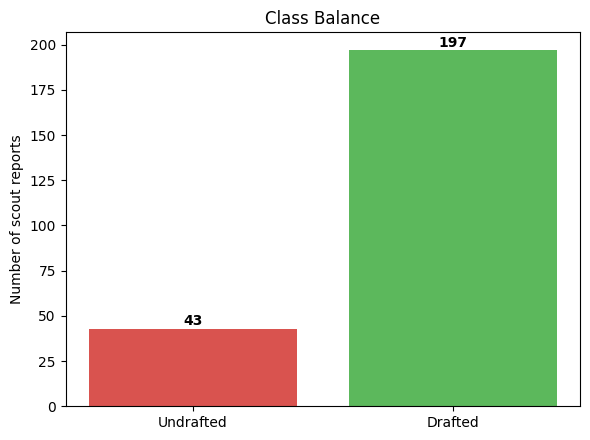

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))

counts = merged["drafted"].value_counts().sort_index()
ax.bar(["Undrafted", "Drafted"], counts.values,
       color=["#d9534f", "#5cb85c"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 2, str(v), ha="center", fontweight="bold")
ax.set_title("Class Balance")
ax.set_ylabel("Number of scout reports")

plt.tight_layout()
plt.show()

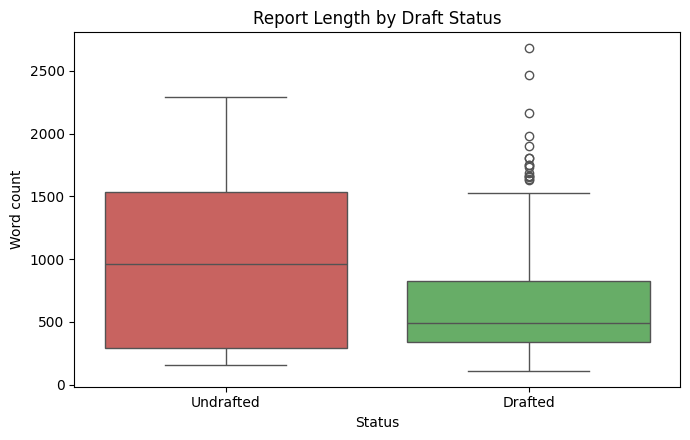

Median word count by group:
drafted
Undrafted    961.0
Drafted      488.0
Name: word_count, dtype: float64


In [ ]:
ig, ax = plt.subplots(figsize=(7, 4.5))

plot_df = merged.assign(
    Status=merged["drafted"].map({0: "Undrafted", 1: "Drafted"})
)
sns.boxplot(data=plot_df, x="Status", y="word_count",
            hue="Status", hue_order=["Undrafted", "Drafted"],
            order=["Undrafted", "Drafted"],
            palette={"Undrafted": "#d9534f", "Drafted": "#5cb85c"},
            legend=False, ax=ax)
ax.set_title("Report Length by Draft Status")
ax.set_ylabel("Word count")

plt.tight_layout()
plt.show()

print("Median word count by group:")
print(merged.groupby("drafted")["word_count"]
      .median().rename({0: "Undrafted", 1: "Drafted"}))

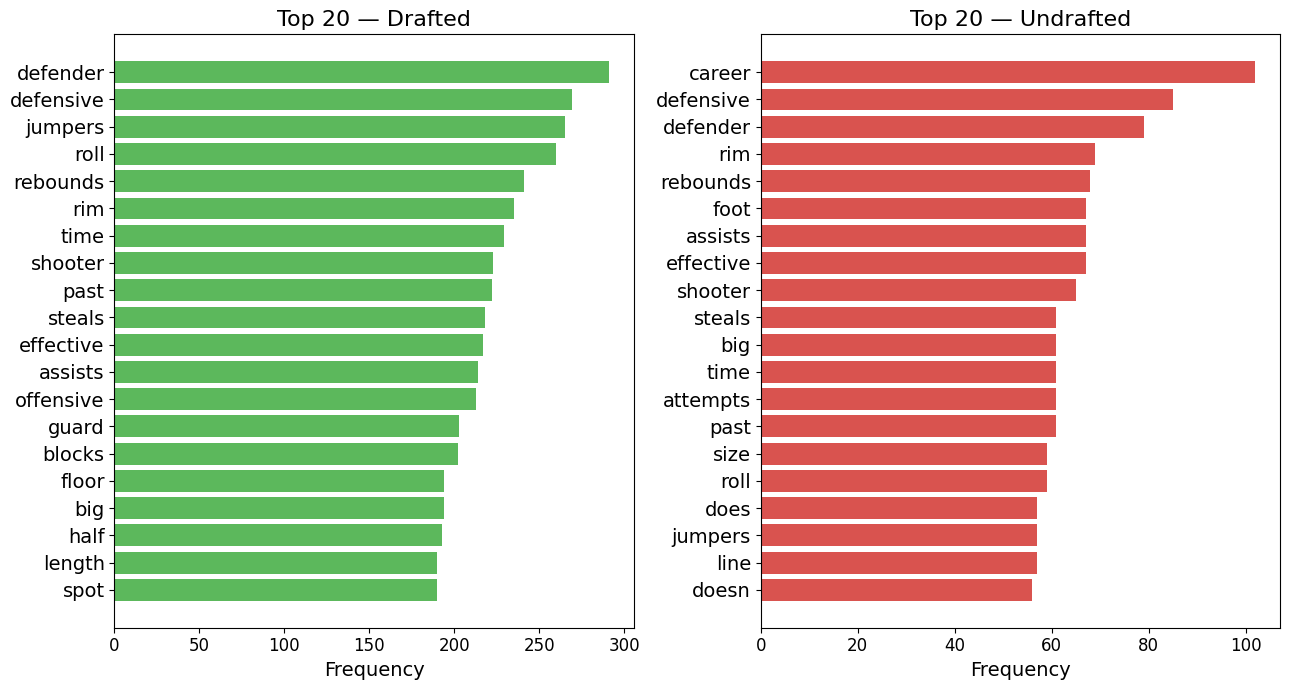

In [ ]:
def top_words(text_series, n=20):
    counter = Counter()
    for doc in text_series:
        counter.update(w for w in doc.split()
                       if w not in STOPWORDS and len(w) > 2)
    return counter.most_common(n)

drafted_top   = top_words(drafted_text, n=20)
undrafted_top = top_words(undrafted_text, n=20)

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, top, title, color in [
    (axes[0], drafted_top,   "Top 20 — Drafted",   "#5cb85c"),
    (axes[1], undrafted_top, "Top 20 — Undrafted", "#d9534f"),
]:
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Frequency", fontsize=14)
    ax.tick_params(axis="y", labelsize=14)   # word labels
    ax.tick_params(axis="x", labelsize=12)   # frequency numbers

plt.tight_layout()
plt.show()

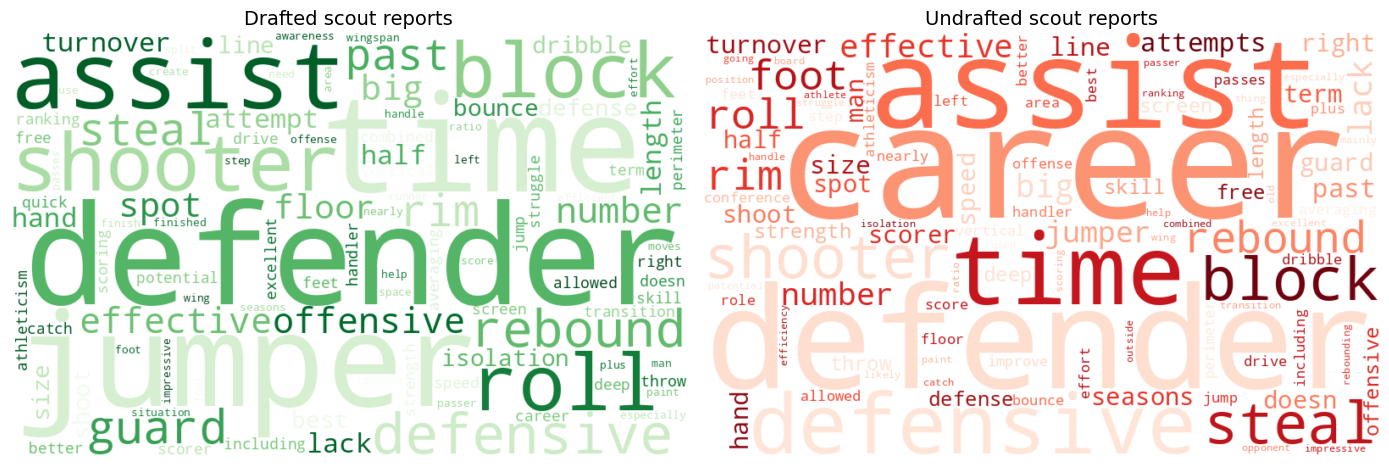

In [ ]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, text_series, title, cmap in [
    (axes[0], drafted_text,   "Drafted",   "Greens"),
    (axes[1], undrafted_text, "Undrafted", "Reds"),
]:
    # Filter out stopwords + names BEFORE generating the cloud,
    # so WordCloud only sees important words
    filtered = " ".join(
        w for doc in text_series
        for w in doc.split()
        if w not in STOPWORDS and len(w) > 2
    )
    wc = WordCloud(
        width=800, height=500,
        background_color="white",
        colormap=cmap,
        max_words=100,
        collocations=False,   # avoid duplicate bigrams sneaking in
    ).generate(filtered)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{title} scout reports", fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()

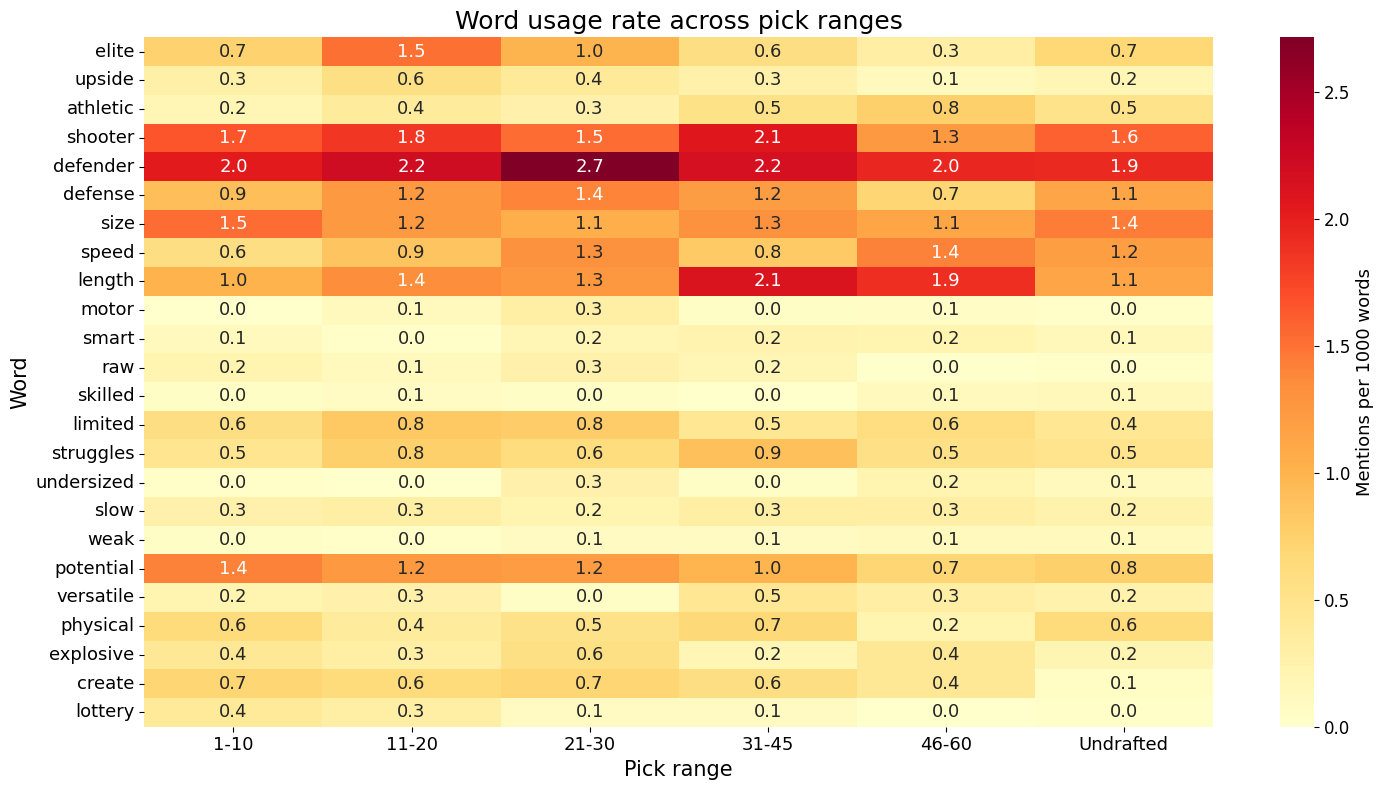

In [ ]:
def pick_bucket(p):
    if p == 0:    return "Undrafted"
    if p <= 10:   return "1-10"
    if p <= 20:   return "11-20"
    if p <= 30:   return "21-30"
    if p <= 45:   return "31-45"
    return "46-60"

merged["bucket"] = merged["pick"].apply(pick_bucket)
bucket_order = ["1-10", "11-20", "21-30", "31-45", "46-60", "Undrafted"]

tracked_words = [
    "elite", "upside", "athletic", "shooter", "defender", "defense",
    "size", "speed", "length", "motor", "smart", "raw",
    "skilled", "limited", "struggles", "undersized", "slow", "weak",
    "potential", "versatile", "physical", "explosive", "create", "lottery",
]

rows = []
for bucket in bucket_order:
    docs = merged.loc[merged["bucket"] == bucket, "clean_text"]
    total_words = sum(len(d.split()) for d in docs) or 1
    counter = Counter()
    for d in docs:
        counter.update(d.split())
    row = {w: 1000 * counter[w] / total_words for w in tracked_words}
    row["bucket"] = bucket
    rows.append(row)

heat_df = pd.DataFrame(rows).set_index("bucket")[tracked_words]

plt.figure(figsize=(15, 8))
ax = sns.heatmap(
    heat_df.T, annot=True, fmt=".1f", cmap="YlOrRd",
    annot_kws={"size": 13},                       # numbers inside cells
    cbar_kws={"label": "Mentions per 1000 words"},
)
ax.set_title("Word usage rate across pick ranges", fontsize=18)
ax.set_xlabel("Pick range", fontsize=15)
ax.set_ylabel("Word", fontsize=15)
ax.tick_params(axis="x", labelsize=13)            # bucket labels
ax.tick_params(axis="y", labelsize=13)            # word labels

# colorbar text
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Mentions per 1000 words", fontsize=13)

plt.tight_layout()
plt.show()

In [ ]:
# Load new/fake undrafted scouting reports generated by ChatGPT
synthetic_undrafted_reports = [
    "Ellison emerged as a steady lead guard for Saint Louis this past season, averaging 14.2 points and 6.8 assists per game while shouldering primary ball-handling duties. At 6-foot-1 with a solid frame, he plays with poise and rarely looks sped up, operating comfortably in pick-and-roll situations. Ellison’s biggest strength is his decision-making. He consistently makes the right read out of ball screens, particularly when manipulating weak-side defenders. He posted 0.98 points per possession (PPP) as a pick-and-roll ball handler, ranking in the 82nd percentile among Division I guards. His passing vision stands out, especially on drive-and-kick sequences, where he’s able to deliver accurate passes to shooters in rhythm. He is also a capable midrange scorer, converting 45% of his pull-up jumpers inside the arc. However, his perimeter shooting remains inconsistent. Ellison shot just 31% from three on moderate volume, and his mechanics—particularly a slow release—limit his effectiveness as a catch-and-shoot threat. Athletically, Ellison is below average by NBA standards. He lacks burst off the dribble and struggles to create separation against more explosive defenders. This limitation shows up at the rim, where he shot just 52%, often relying on floaters rather than finishing through contact. Defensively, Ellison competes but has limitations. His lateral quickness is average, and he can be targeted in isolation. He also tends to die on screens, which reduces his effectiveness in switch-heavy schemes. Ellison projects as a high-IQ floor general, but questions about his athletic ceiling and perimeter shooting will weigh heavily in evaluations.",
    "Bates is a physically imposing 6-foot-5 shooting guard who averaged 16.8 points per game in the SEC. He thrives as a downhill attacker, using his strength to get to the rim and absorb contact. He excels in transition, where he generates 1.21 PPP (78th percentile), often finishing above the rim or drawing fouls. In the half court, Bates is most effective when attacking closeouts, leveraging his straight-line speed and physicality. However, his perimeter shooting is a major concern. Bates shot just 29% from three, and defenders routinely go under screens against him. His shot selection can also be questionable, as he tends to settle for contested midrange attempts. His ball-handling is functional but not advanced. He struggles to change direction effectively, limiting his ability to create space against disciplined defenders. This also contributes to his turnover rate, which hovered near 18%. Defensively, Bates has the tools to be impactful but is inconsistent. He can lock in and use his strength to contain drives, but his off-ball awareness is lacking, often leading to missed rotations. Bates’ physical tools and scoring ability are intriguing, but his lack of shooting and limited shot creation raise concerns about his role at the next level.",
    "Novak is a 6-foot-7 wing known for his shooting ability and off-ball movement. He averaged 13.5 points per game while shooting 38% from three on high volume. He thrives in catch-and-shoot situations, posting 1.22 PPP (85th percentile). Novak moves well without the ball, using screens and relocating effectively to find open looks. His quick release allows him to get shots off against closeouts. However, Novak offers limited value as a shot creator. He struggles to generate offense off the dribble and rarely attacks the rim. When forced to put the ball on the floor, he becomes predictable and turnover-prone. Athletically, Novak is average. He lacks explosiveness and has difficulty finishing through contact, converting just 48% of his attempts at the rim. Defensively, Novak competes but is limited laterally. He struggles to stay in front of quicker wings and can be targeted in isolation. While he understands team defensive concepts, his physical limitations cap his impact. Novak’s shooting gives him a clear pathway to a role, but his lack of versatility and athletic upside may limit his ceiling.",
    "Whitaker is an undersized power forward at 6-foot-7 who relies heavily on energy and effort. He averaged 11.9 points and 9.3 rebounds per game, serving as a high-motor presence in the frontcourt. He excels as a rebounder, particularly on the offensive glass, where he generated 3.1 second-chance opportunities per game. His activity level is consistently high, and he plays with a physical edge. Offensively, Whitaker scores primarily around the rim, finishing cuts and putbacks efficiently. However, his lack of shooting range is a major limitation. He attempted just 12 three-pointers all season and does not stretch the floor. Defensively, Whitaker is versatile in certain contexts. He can switch onto wings for short stretches, but his lack of length (6-foot-9 wingspan) limits his ability to contest shots effectively. He also struggles against bigger post players. Whitaker’s energy and rebounding are valuable, but his positional limitations and lack of offensive skill diversity raise questions about his fit.",
    "Petrovic is a 7-foot center with a traditional back-to-the-basket game. He averaged 12.4 points and 7.8 rebounds, showcasing polished footwork in the post. He is effective in low-post situations, scoring 0.97 PPP on post-ups. His touch around the rim is soft, and he uses his size well to create space. However, Petrovic’s mobility is a concern. He struggles in pick-and-roll defense, particularly when asked to hedge or switch. Opponents targeted him in space, exploiting his lack of lateral quickness. Offensively, he offers little outside the paint. He does not shoot from the perimeter and is not a dynamic roll man. His lack of vertical explosiveness limits his effectiveness as a lob threat. Defensively, while he provides some rim protection, his impact is inconsistent. He averaged just 1.1 blocks per game and can be slow to rotate. Petrovic’s size and post skill are notable, but his lack of mobility and modern offensive versatility limit his appeal.",
    "Mercer is a 6-foot-2 lead guard who averaged 15.4 points and 6.3 assists, operating as Temple’s primary initiator. He plays with good tempo and shows an advanced understanding of pick-and-roll reads, particularly hitting the roll man and weak-side shooters. Mercer posted 1.00 PPP as a pick-and-roll ball handler, demonstrating solid efficiency and control. He is most comfortable scoring from the midrange, where he converted 45% of his pull-up attempts. However, his three-point shooting remains inconsistent (31%), and his release can be somewhat deliberate, allowing defenders to recover. Mercer also struggles finishing at the rim (50%), often relying on floaters due to limited vertical explosiveness. Defensively, Mercer competes but has clear physical limitations. His lateral quickness is average, and he can be targeted in isolation or when switching onto bigger guards. He also has a tendency to get caught on screens. Mercer’s feel, passing, and composure stand out, but his lack of athletic upside and perimeter shooting consistency raise concerns about his long-term role.",
    "Price is a 6-foot-2 lead guard who averaged 16.7 points and 6.9 assists while serving as the primary offensive engine for Georgia Tech. He plays with a composed tempo and demonstrates a strong understanding of how to manipulate defenses in pick-and-roll situations. Price consistently keeps defenders on his hip and shows advanced timing when delivering pocket passes or hitting weak-side shooters. He generated 1.01 points per possession (PPP) as a pick-and-roll ball handler, ranking among the more efficient high-usage guards in his conference. As a scorer, Price is most comfortable operating in the midrange, where he converted 45% of his pull-up attempts. He has a reliable floater package and shows touch from 8–15 feet, which helps compensate for his struggles finishing at the rim. He shot just 51% around the basket, often avoiding contact due to a lack of vertical explosiveness and strength. His three-point shooting remains inconsistent at 32%, and his release can be somewhat deliberate, allowing defenders to close out effectively. While he is capable of making open shots, he does not consistently command defensive attention beyond the arc. Defensively, Price competes but faces physical limitations. His lateral quickness is average, and he can be targeted by quicker or stronger guards in isolation. He also has difficulty navigating screens, which reduces his effectiveness in pick-and-roll coverage. Off the ball, he shows solid awareness but can occasionally lose track of his assignment when helping. Price’s combination of feel, passing, and control gives him a foundation as a floor general. However, his lack of elite athleticism, inconsistent perimeter shooting, and defensive limitations raise concerns about his ability to consistently impact games against higher-level competition. His projection will likely depend on whether he can improve his shooting efficiency and physical profile.",
    "Rutherford is a 6-foot-5 scoring guard who averaged 18.2 points per game and was one of Auburn’s primary offensive options. He is an aggressive shot creator who thrives in isolation, using a combination of crossovers, hesitations, and step-backs to generate space. Rutherford is comfortable taking difficult shots late in the shot clock and has shown the ability to heat up quickly, scoring in bursts when he finds a rhythm. Despite his scoring production, efficiency is a concern. Rutherford shot 41% from the field and 30% from three, often settling for contested jumpers rather than attacking the rim consistently. While he has the physical tools to get downhill, he tends to rely heavily on pull-up attempts, which lowers his overall efficiency. His shot selection can be questionable, particularly early in possessions, and he has a tendency to predetermine his moves rather than reading the defense. Rutherford is not a natural playmaker, averaging just 2.3 assists per game. He can struggle to recognize open teammates, especially when driving into traffic, and his decision-making contributes to a relatively high turnover rate. His handle is functional but can become loose under pressure, particularly against disciplined defenders. Defensively, Rutherford has the size and athletic tools to be effective, but his effort and consistency fluctuate. He can defend on-ball in spurts, using his length to contest shots, but he often loses focus off-ball and can be late on rotations. His rebounding is average for his position. Rutherford’s shot-making ability and scoring instincts are intriguing, but his inefficiency, limited playmaking, and inconsistent defensive engagement raise concerns about how his skill set will translate in a more structured role.",
    "Henderson is a 6-foot-7 wing who averaged 13.4 points and shot 38% from three, serving as a reliable floor spacer. He thrives in catch-and-shoot situations, posting 1.23 PPP on spot-up opportunities, and shows a strong understanding of off-ball movement. Henderson consistently relocates along the perimeter and uses screens effectively to create open looks. His quick release allows him to get shots off before defenders can fully contest. While Henderson’s shooting is his primary strength, his offensive game is otherwise limited. He struggles to create offense off the dribble, lacking the burst and handle needed to consistently beat defenders. When forced to put the ball on the floor, he becomes predictable and is prone to turnovers. His finishing ability is below average, as he converted just 48% of his attempts at the rim, often struggling to absorb contact or elevate over defenders. Defensively, Henderson competes and understands team concepts, but his physical tools limit his effectiveness. He has average lateral quickness and can be targeted by quicker wings in isolation. While he uses his size to contest shots, he does not provide significant rim protection or disruptive playmaking. Henderson’s shooting gives him a clear pathway to contributing as a floor spacer, but his lack of shot creation, limited athleticism, and defensive limitations raise questions about his overall versatility and long-term ceiling.",
    "McClain is a 6-foot-2 point guard who averaged 17.1 points and 7.2 assists while serving as Missouri’s primary offensive engine. He plays with a composed pace and demonstrates a strong understanding of how to manipulate defenses in pick-and-roll situations. McClain excels at keeping defenders off balance with hesitations and changes of speed, and he consistently makes the correct read, particularly when hitting rollers or weak-side shooters. He posted 1.03 points per possession (PPP) as a pick-and-roll ball handler, ranking among the more efficient high-usage guards in his conference. As a scorer, McClain is most comfortable operating in the midrange. He converted 46% of his pull-up jumpers inside the arc and shows a reliable floater game. However, his three-point shooting remains inconsistent at 32%, and his release can be somewhat slow, allowing defenders to recover. At the rim, he shot just 51%, often avoiding contact due to limited strength and vertical explosiveness. His lack of elite burst makes it difficult for him to consistently beat defenders off the dribble, especially against more athletic opponents. Defensively, McClain competes and shows solid awareness, but his physical tools limit his effectiveness. His lateral quickness is average, and he can be targeted by quicker guards in isolation. He also struggles navigating screens, which reduces his effectiveness in pick-and-roll coverage. Off the ball, he is generally sound but can lose track of his assignment when overhelping. McClain’s feel for the game, passing ability, and composure as a lead guard are clear strengths. However, his lack of elite athleticism, inconsistent perimeter shooting, and defensive limitations raise concerns about his long-term projection and ability to consistently create advantages at the next level.",

    "Pierce is a 6-foot-5 scoring guard who averaged 18.6 points and was one of LSU’s primary offensive options. He is an aggressive shot creator who thrives in isolation, using step-backs, crossovers, and hesitation moves to generate space. Pierce has the ability to score in bunches and is comfortable taking difficult shots late in the shot clock. Despite his scoring production, efficiency is a major concern. Pierce shot 41% from the field and 30% from three, often settling for contested jumpers rather than attacking the rim consistently. His shot selection can be questionable, particularly early in possessions, and he has a tendency to predetermine his moves instead of reading the defense. Pierce is not a natural playmaker, averaging just 2.3 assists per game. He can struggle to recognize open teammates and often forces shots in traffic. His handle is functional but can become loose under pressure, leading to turnovers. Defensively, Pierce has the physical tools to be effective, but his effort and consistency fluctuate. He can defend on-ball in spurts, using his length to contest shots, but he often loses focus off-ball and is prone to missed rotations. His rebounding is average for his position. Pierce’s shot-making ability and scoring instincts are intriguing, but his inefficiency, limited playmaking, and inconsistent defensive engagement raise concerns about his ability to contribute within a structured system.",
    "Bailey is a 6-foot-2 lead guard who averaged 16.8 points and 6.6 assists, functioning as the primary initiator. He plays with controlled pace and demonstrates a strong understanding of pick-and-roll reads, particularly manipulating the weak-side help defender. Bailey posted 1.02 points per possession (PPP) as a pick-and-roll ball handler, showing the ability to consistently generate quality looks for teammates. His vision is a clear strength, especially when delivering passes on the move or finding shooters in rhythm. As a scorer, Bailey is most comfortable in the midrange, converting 45% of his pull-up attempts. He also shows touch with floaters in the lane. However, his three-point shooting is inconsistent (32%), and defenders are often willing to go under screens. His release can be somewhat slow, limiting his effectiveness as a catch-and-shoot option. At the rim, Bailey struggles finishing through contact (51%), lacking elite explosiveness and strength. Defensively, Bailey competes and understands team concepts, but his physical tools limit his impact. His lateral quickness is average, and he can be targeted by quicker or stronger guards. He also has difficulty navigating screens, which impacts his effectiveness in pick-and-roll defense. Bailey’s feel, passing ability, and control give him a solid foundation as a floor general, but his lack of athletic upside and inconsistent shooting raise concerns about his long-term projection.",
    "Keller is a 6-foot-8 forward who averaged 13.8 points, 7.1 rebounds, and 2.4 assists, functioning as a versatile offensive piece in Northwestern’s system. He was often utilized as a secondary creator, operating from the elbows and high post, where his ability to make reads and facilitate stood out. Keller shows a strong feel for the game, particularly when attacking closeouts or initiating dribble handoffs, and he demonstrated solid decision-making for a forward, posting a respectable assist-to-turnover ratio. Offensively, Keller is most effective as a face-up scorer. He has a smooth midrange game, converting 43% of his attempts from 10–18 feet, and is comfortable attacking slower defenders off the dribble. He also shows flashes of playmaking, particularly when drawing help and finding cutters. However, his perimeter shooting remains inconsistent. Keller shot just 31% from three, and his mechanics can be rigid, with a slow, deliberate release that limits his ability to get shots off against closeouts. Defenders are often willing to give him space beyond the arc, which impacts overall spacing. Keller’s finishing at the rim is another area of concern. Despite his size, he lacks elite explosiveness and vertical pop, converting just 52% of his attempts around the basket. He tends to avoid contact rather than absorb it, and stronger defenders can knock him off balance. While he has decent body control, his lack of strength shows up when finishing in traffic. Defensively, Keller offers some positional versatility due to his size, but his effectiveness is inconsistent. He can guard forwards in isolation and has shown the ability to switch onto wings for short stretches, but his lateral quickness is average, and he struggles to stay in front of quicker players. Off the ball, he has a tendency to lose focus, occasionally missing rotations or being late on help-side responsibilities. He is not a significant rim protector, averaging under one block per game, and his wingspan does not provide much margin for error. Keller is a solid rebounder, particularly on the defensive glass, where he uses positioning and timing rather than athleticism. He averaged over seven rebounds per game, though he is not a dominant presence in contested situations. Overall, Keller’s versatility, feel, and midrange scoring provide some intrigue, especially as a connective piece offensively. However, his lack of a clearly defined elite skill—combined with inconsistent shooting, limited athleticism, and defensive inconsistency—raises questions about how his game translates to higher levels.",
    "Grant is a 6-foot-8 forward who averaged 12.9 points, 7.4 rebounds, and 2.1 assists, functioning as a versatile frontcourt piece in Illinois’ rotation. He brings a solid physical profile with a strong frame and shows flashes of being able to impact the game in multiple areas. Offensively, Grant operates primarily as a face-up forward, often catching the ball at the elbows or on the perimeter and attacking slower defenders off the dribble. He is comfortable taking midrange jumpers, converting 42% from that area, and shows some ability to create his own shot in isolation situations. Grant’s three-point shooting, however, remains inconsistent. He shot just 30% from beyond the arc on low-to-moderate volume, and his mechanics can be rigid, particularly on quicker catch-and-shoot attempts. Defenders are often willing to give him space, which affects spacing in half-court sets. While he has shown flashes of extending his range, it is not yet a reliable part of his offensive game. Around the basket, Grant is a capable but not elite finisher. He converted 53% of his attempts at the rim, often relying on touch rather than explosiveness. He lacks vertical pop and can struggle to finish through contact against longer defenders. His handle is functional for a forward but can become loose when he is forced to navigate traffic, leading to occasional turnovers. Defensively, Grant has the size to guard multiple positions, but his effectiveness is inconsistent. He can match up with forwards and hold his ground in the post, but his lateral quickness is average, which makes it difficult for him to stay in front of quicker wings. Off the ball, he shows effort but can lose focus, leading to missed rotations or late closeouts. He is not a major rim-protection presence, averaging under one block per game, and does not provide significant disruption as a help defender. Grant is a solid rebounder, particularly on the defensive glass, where he uses positioning and timing to secure boards. He averaged over seven rebounds per game, though he is not dominant in contested situations. Overall, Grant’s combination of size, versatility, and scoring ability provides some intrigue, but his lack of a consistent perimeter shot, limited athleticism, and defensive inconsistency raise questions about how clearly his role translates at the next level.",
    "Whitmore is a 6-foot-5 shooting guard who averaged 15.2 points, 4.8 rebounds, and 2.3 assists while playing a significant offensive role at Kansas. He is a confident perimeter scorer who operates best in structured half-court sets, particularly as a secondary option. Whitmore shows a solid understanding of spacing and is effective relocating along the perimeter, making himself available as a catch-and-shoot threat. He converted 36% of his three-point attempts, with most of his success coming on spot-up opportunities rather than off-the-dribble looks. Whitmore’s offensive game is built around his ability to score from the perimeter and midrange. He is comfortable pulling up from 12–18 feet and has a relatively smooth shooting motion, though his release can be slightly slow when tightly contested. While he can attack closeouts, his handle is not advanced, and he tends to rely on straight-line drives rather than creating separation with change-of-direction moves. This limitation affects his ability to consistently get to the rim, where he converted just 49% of his attempts. He often avoids contact rather than embracing it, which limits his effectiveness finishing in traffic. As a playmaker, Whitmore is serviceable but not a primary creator. He can make basic reads when the defense collapses, but he does not consistently create advantages for others. His assist numbers reflect a player who operates more as a scorer than a facilitator, and he can be turnover-prone when trying to force passes into tight windows. Defensively, Whitmore has adequate size for his position, but his overall impact is inconsistent. He competes on-ball and can contest shots effectively when engaged, but his lateral quickness is average, making it difficult for him to stay in front of quicker guards. Off the ball, he can lose focus, occasionally missing rotations or giving up backdoor cuts. While he has the physical tools to be a capable defender, his awareness and consistency remain areas for improvement. Whitmore is a solid rebounder for a guard, using his size to contribute on the defensive glass. Overall, his shooting and scoring ability provide some value, but his lack of elite athleticism, limited shot creation, and inconsistent defensive engagement raise questions about how his role translates at higher levels.",
    "Caldwell is a 6-foot-6 wing who averaged 14.3 points, 4.9 rebounds, and 2.2 assists, operating as a complementary scoring option within Villanova’s system. He plays with a high level of discipline and understands how to function within structured offensive sets, particularly as a floor spacer and secondary attacker. Caldwell shot 37% from three-point range, with the majority of his attempts coming in catch-and-shoot situations, where he posted strong efficiency. He moves well without the ball, consistently relocating along the perimeter and using screens to create open looks. Despite his effectiveness as a spot-up shooter, Caldwell’s offensive game has limitations. He struggles to create his own shot off the dribble, lacking the burst and handle necessary to consistently beat defenders. When he does attack closeouts, he tends to rely on straight-line drives and can become predictable. His finishing at the rim is below average (49%), as he often avoids contact and lacks the explosiveness to finish over length. While he has shown flashes of a midrange pull-up game, it is not yet a consistent weapon. As a playmaker, Caldwell is serviceable but not dynamic. He can make basic reads when the defense collapses, but he does not consistently create advantages for teammates. His assist numbers reflect a player who operates more as a scorer than a facilitator, and he can struggle when asked to handle extended on-ball responsibilities. Defensively, Caldwell has adequate size and competes on that end, but his impact is inconsistent. He can hold his own against similarly sized wings, but his lateral quickness is average, which makes it difficult for him to stay in front of quicker players. Off the ball, he generally understands team defensive principles but can occasionally lose focus, leading to late rotations or missed assignments. Caldwell is a solid rebounder for his position, using positioning and effort to contribute on the defensive glass. Overall, his shooting and understanding of team concepts provide a foundation, but his lack of shot creation, average athletic profile, and inconsistent defensive impact raise questions about how clearly his role translates at higher levels.",
    "Rivas is a 6-foot-1 point guard who averaged 15.8 points, 6.2 assists, and 3.9 rebounds, serving as the primary ball handler in San Diego State’s offense. He plays with a controlled tempo and demonstrates a strong understanding of pick-and-roll concepts, consistently probing the defense and making reads based on help coverage. Rivas posted 0.98 points per possession (PPP) as a pick-and-roll ball handler, showing the ability to generate efficient looks for both himself and his teammates. His passing vision is a clear strength, particularly when hitting the roller or finding shooters in the corners. As a scorer, Rivas is most comfortable operating in the midrange. He converted 44% of his pull-up jumpers inside the arc and shows a reliable floater game in the lane. However, his three-point shooting remains inconsistent, as he shot 31% from beyond the arc on moderate volume. His release is somewhat deliberate, which allows defenders to recover and contest. At the rim, Rivas converted just 50% of his attempts, often struggling to finish through contact due to his lack of strength and vertical explosiveness. Rivas’ handle is steady but not particularly dynamic. While he can navigate ball screens effectively, he lacks the burst to consistently create separation against quicker defenders. This limitation shows up when he is forced into isolation situations, where he can struggle to generate clean looks. Defensively, Rivas competes and shows good awareness, but his physical tools limit his impact. His lateral quickness is average, and he can be targeted by larger or more athletic guards. He also has difficulty fighting through screens, which affects his ability to stay attached in pick-and-roll coverage. Off the ball, he generally understands team defensive principles but can occasionally be late on rotations. Overall, Rivas’ feel for the game, passing ability, and composure as a lead guard provide a solid foundation. However, his lack of elite athleticism, inconsistent perimeter shooting, and defensive limitations raise questions about his ability to consistently create advantages and hold up against higher-level competition.",
    "Lawson is a 6-foot-6 wing who averaged 14.9 points, 5.1 rebounds, and 2.0 assists, operating primarily as a perimeter scorer in Michigan’s offense. He plays within the flow of the system and shows a solid understanding of spacing, frequently positioning himself along the arc or on the weak side to capitalize on defensive rotations. Lawson shot 36% from three-point range, with most of his production coming in catch-and-shoot situations. He is comfortable shooting with his feet set and has a relatively compact release, allowing him to get shots off before defenders fully close out. While Lawson’s perimeter shooting is a strength, the rest of his offensive game remains somewhat limited. He struggles to consistently create his own shot off the dribble, lacking the burst and handle needed to beat defenders in isolation. When attacking closeouts, he tends to rely on straight-line drives, which can become predictable. This limitation impacts his finishing ability, as he converted just 49% of his attempts at the rim. He often avoids contact rather than finishing through it, and longer defenders can disrupt his attempts. As a playmaker, Lawson is not heavily relied upon. He can make basic reads when the defense collapses, but he does not consistently create advantages for others. His assist numbers reflect a player who is more comfortable as a finisher than a facilitator, and he can be turnover-prone when asked to handle extended on-ball responsibilities. Defensively, Lawson has adequate size for a wing, but his overall impact is inconsistent. He competes on-ball and can contest shots effectively when engaged, but his lateral quickness is average, which makes it difficult for him to stay in front of quicker players. Off the ball, he generally understands team defensive concepts but can lose focus at times, leading to missed rotations or late closeouts. Lawson contributes as a rebounder for his position, using his size and positioning to secure defensive boards. Overall, his shooting and understanding of team offense provide a foundation, but his lack of shot creation, average athletic profile, and inconsistent defensive engagement raise questions about how clearly his role translates at higher levels.",
    "Bennett is a 6-foot-8 forward who averaged 13.2 points, 7.6 rebounds, and 1.8 assists while playing a versatile role in Syracuse’s lineup. He operated primarily as a face-up forward, often catching the ball at the elbows or along the perimeter and attacking slower defenders off the dribble. Bennett shows a solid understanding of spacing and is comfortable making quick decisions within the flow of the offense, particularly when attacking closeouts or moving the ball to open teammates. Offensively, Bennett’s game is built around midrange scoring and interior finishing. He converted 43% of his attempts from 10–18 feet and shows a relatively smooth release when shooting in rhythm. However, his three-point shooting remains inconsistent, as he shot just 30% from beyond the arc. His mechanics can be somewhat rigid, and his release slows down when contested, limiting his effectiveness as a reliable floor spacer. Bennett’s handle is functional for his position, allowing him to attack in straight lines, but he lacks the burst and change-of-direction ability to consistently beat defenders off the dribble. This limitation affects his finishing at the rim, where he converted 52% of his attempts. While he has decent touch, he tends to avoid contact and can struggle against longer or more physical defenders. Defensively, Bennett has the size to guard multiple positions, but his overall impact is inconsistent. He can match up with forwards and hold his ground in the post, but his lateral quickness is average, making it difficult for him to stay in front of quicker wings. Off the ball, he shows effort but can lose focus, occasionally missing rotations or being late on closeouts. He is not a significant rim protector, averaging under one block per game, and does not provide much defensive playmaking. Bennett is a solid rebounder, particularly on the defensive glass, where he uses positioning and effort to secure boards. Overall, his size, versatility, and midrange scoring provide some intrigue, but his inconsistent perimeter shooting, limited athleticism, and lack of a clearly defined elite skill raise questions about how his role translates at higher levels.",
    "Whitaker is a 6-foot-3 combo guard who averaged 15.0 points, 4.2 rebounds, and 3.8 assists while playing a hybrid on-ball/off-ball role in Clemson’s backcourt. He operates comfortably within structured offense and shows a solid understanding of spacing, often relocating along the perimeter to create passing angles or catch-and-shoot opportunities. Whitaker shot 35% from three-point range, with most of his success coming on spot-up looks rather than off-the-dribble attempts. His mechanics are generally clean, though his release can be slightly deliberate, which limits his effectiveness against hard closeouts. As a scorer, Whitaker is most effective attacking closeouts and operating in the midrange. He converted 43% of his pull-up jumpers inside the arc and shows a decent floater when navigating traffic. However, he lacks the burst to consistently create separation against defenders, which impacts his ability to generate high-quality looks. His handle is functional but not advanced, and he can struggle when forced to change direction under pressure. At the rim, he converted just 50% of his attempts, often avoiding contact rather than finishing through it. Whitaker’s playmaking is adequate but not a standout aspect of his game. He can make basic reads and deliver accurate passes in simple situations, but he does not consistently create advantages for teammates. When asked to initiate offense for extended stretches, he can become turnover-prone, particularly when trying to force passes into tight windows. Defensively, Whitaker has decent size for a guard, but his impact is inconsistent. He competes on-ball and can contest shots effectively when engaged, but his lateral quickness is average, making it difficult to stay in front of quicker guards. Off the ball, he shows a general understanding of team concepts but can lose focus, leading to late rotations or missed assignments. Whitaker contributes as a rebounder for his position and plays with a steady approach, but his overall profile is that of a complementary guard. His shooting, positional size, and offensive versatility provide some value, but his lack of elite athleticism, limited shot creation, and inconsistent defensive impact raise questions about how clearly his role translates at higher levels.",

    "Brooks is a 6-foot-7 wing who averaged 13.7 points, 5.5 rebounds, and 2.1 assists while playing a complementary scoring role in Maryland’s offense. He operates primarily off the ball, showing a solid understanding of spacing and timing, particularly when working off screens or relocating along the perimeter. Brooks shot 37% from three-point range on moderate volume, with most of his production coming in catch-and-shoot situations. His shooting mechanics are compact and repeatable, allowing him to be a reliable spot-up option when his feet are set. While Brooks’ perimeter shooting is a clear strength, his offensive game becomes more limited when asked to create his own shot. He lacks the burst and handle necessary to consistently beat defenders off the dribble, relying mostly on straight-line drives when attacking closeouts. This predictability makes him easier to defend, especially against more disciplined defenders. At the rim, he converted 49% of his attempts, often struggling to finish through contact or elevate over length due to average explosiveness. Brooks shows flashes of a midrange game, particularly on pull-ups inside 15 feet, but it is not yet a consistent part of his offensive arsenal. As a playmaker, he is serviceable but not dynamic, capable of making simple reads but not consistently creating advantages for teammates. His assist numbers reflect a player who is more comfortable finishing plays than initiating them. Defensively, Brooks has the size to guard multiple positions, but his impact is inconsistent. He competes on-ball and can contest shots effectively, but his lateral quickness is average, making it difficult for him to stay in front of quicker wings. Off the ball, he generally understands team defensive principles but can lose focus at times, leading to missed rotations or late closeouts. Brooks is a solid rebounder for his position, using positioning and effort to contribute on the defensive glass. Overall, his shooting and understanding of team offense provide a foundation, but his lack of shot creation, average athletic profile, and inconsistent defensive engagement raise questions about how clearly his role translates at higher levels.",
    "Mitchell is a 6-foot-4 combo guard who averaged 15.5 points, 4.1 assists, and 3.6 rebounds while playing a dual role as both a secondary ball handler and perimeter scorer. He operates comfortably within structured offensive sets and shows a solid understanding of spacing, often positioning himself effectively along the arc or attacking gaps created by primary initiators. Mitchell shot 35% from three-point range, with most of his success coming in catch-and-shoot situations. His mechanics are generally consistent, though his release can be slightly slow when closely contested. As a scorer, Mitchell is most effective attacking closeouts and operating in the midrange. He converted 43% of his pull-up jumpers inside the arc and has a decent floater when navigating traffic. However, his ability to create separation off the dribble is limited. His handle is functional but not advanced, and he struggles to change direction effectively against more athletic defenders. This limitation affects his finishing ability, as he converted just 50% of his attempts at the rim, often avoiding contact rather than finishing through it. Mitchell’s playmaking is adequate but not a defining strength. He can make basic reads and deliver accurate passes in simple situations, but he does not consistently create advantages for teammates. When tasked with extended on-ball responsibilities, he can become turnover-prone, particularly when attempting to force passes into tight windows. Defensively, Mitchell has good size for a guard and shows flashes of being able to guard multiple positions. However, his impact is inconsistent. He competes on-ball and can contest shots effectively when engaged, but his lateral quickness is average, making it difficult for him to stay in front of quicker guards. Off the ball, he can lose focus at times, leading to missed rotations or late closeouts. Mitchell contributes as a rebounder for his position and plays with a steady approach, but his overall profile is that of a complementary guard. His shooting, positional size, and versatility provide some value, but his lack of elite athleticism, limited shot creation, and inconsistent defensive engagement raise questions about how clearly his role translates at higher levels.",
    "Cole is a 6-foot-6 wing who averaged 14.1 points, 5.0 rebounds, and 2.3 assists, functioning primarily as a complementary scorer within Vanderbilt’s offense. He shows a good understanding of spacing and is most effective operating off the ball, where he consistently relocates along the perimeter and uses screens to find open looks. Cole shot 36% from three-point range, with the majority of his attempts coming in catch-and-shoot situations. His shooting mechanics are relatively clean, though his release can be slightly slow, particularly when defenders close out aggressively. As a scorer, Cole relies heavily on perimeter shooting and midrange pull-ups. He converted 42% of his attempts from 12–18 feet, showing some comfort creating space with one or two dribbles. However, his ability to consistently generate offense off the dribble is limited. He lacks the burst and handle to beat defenders in isolation, often resorting to straight-line drives when attacking closeouts. This predictability affects his efficiency at the rim, where he converted just 49% of his attempts. He tends to avoid contact and can struggle finishing over length or through physical defenders. Cole’s playmaking is serviceable but not a major part of his game. He can make basic reads when defenses collapse, but he does not consistently create advantages for teammates. His assist numbers reflect a player who operates more as a finisher than a facilitator, and he can become turnover-prone when asked to take on extended ball-handling duties. Defensively, Cole has the size to guard multiple positions, but his impact is inconsistent. He competes on-ball and can contest shots effectively, but his lateral quickness is average, which makes it difficult for him to stay in front of quicker wings. Off the ball, he generally understands team defensive concepts but can lose focus, leading to missed rotations or late closeouts. Cole is a solid rebounder for his position, using positioning and effort to secure boards on the defensive glass. Overall, his shooting and size provide a foundation, but his lack of shot creation, average athleticism, and inconsistent defensive engagement raise questions about how clearly his role translates at higher levels.",
    "Mercer is a 6-foot-2 point guard who averaged 15.6 points, 6.0 assists, and 3.5 rebounds while serving as Oregon State’s primary ball handler. He plays with a controlled pace and shows a strong understanding of how to operate in pick-and-roll, consistently probing the defense and making reads based on coverage. Mercer is particularly effective delivering pocket passes and finding weak-side shooters, posting 0.97 points per possession (PPP) as a pick-and-roll ball handler. His composure and decision-making allow him to keep the offense organized in half-court sets. As a scorer, Mercer relies heavily on midrange pull-ups and floaters. He converted 44% of his attempts from 10–18 feet and shows good touch in the lane. However, his three-point shooting remains inconsistent, as he shot 31% from beyond the arc on moderate volume. His release can be somewhat deliberate, which allows defenders to recover or go under screens. At the rim, Mercer converted just 50% of his attempts, often struggling to finish through contact due to his lack of strength and vertical explosiveness. Mercer’s handle is steady but not particularly dynamic. While he can navigate ball screens effectively, he lacks the burst to consistently create separation against more athletic defenders. This limitation shows up when he is forced into isolation situations, where he can struggle to generate clean looks for himself. Defensively, Mercer competes and shows awareness, but his physical tools limit his impact. His lateral quickness is average, and he can be targeted by larger or quicker guards. He also has difficulty fighting through screens, which impacts his effectiveness in pick-and-roll coverage. Off the ball, he generally understands team defensive principles but can occasionally be late on rotations. Overall, Mercer’s feel for the game, passing ability, and composure as a lead guard provide a solid foundation. However, his lack of elite athleticism, inconsistent perimeter shooting, and defensive limitations raise questions about his ability to consistently create advantages and hold up against higher-level competition.",
    "Alvarez is a 6-foot-6 wing who averaged 14.8 points, 5.6 rebounds, and 2.4 assists while operating as a complementary scorer in Florida State’s rotation. He plays with a steady pace and shows a good understanding of spacing, frequently positioning himself along the perimeter or cutting into open lanes when defenses shift. Alvarez shot 35% from three-point range, with most of his production coming in catch-and-shoot situations. His mechanics are generally clean, though his release can be somewhat slow when defenders close out aggressively. As a scorer, Alvarez is most effective attacking closeouts and working in the midrange. He converted 43% of his pull-up jumpers inside the arc and shows a decent floater when navigating traffic. However, his ability to create his own shot is limited. He lacks the burst and advanced handle needed to consistently beat defenders off the dribble, often relying on straight-line drives that can become predictable. This limitation affects his finishing at the rim, where he converted just 50% of his attempts. He tends to avoid contact rather than finishing through it, which reduces his efficiency against longer defenders. Alvarez’s playmaking is functional but not a defining strength. He can make basic reads and deliver accurate passes in simple situations, but he does not consistently create advantages for teammates. When tasked with extended on-ball responsibilities, he can become turnover-prone, particularly when forcing passes into tight windows. Defensively, Alvarez has adequate size to guard multiple positions, but his overall impact is inconsistent. He competes on-ball and can contest shots effectively, but his lateral quickness is average, making it difficult to stay in front of quicker wings. Off the ball, he shows a general understanding of team concepts but can lose focus, leading to missed rotations or late closeouts. Alvarez contributes as a rebounder for his position, using his size and positioning to secure defensive boards. Overall, his shooting, size, and understanding of team offense provide a foundation, but his lack of shot creation, average athletic profile, and inconsistent defensive engagement raise questions about how clearly his role translates at higher levels.",
    "Dawson is a 6-foot-3 combo guard who averaged 15.1 points, 4.5 assists, and 3.7 rebounds while playing a dual role as both a secondary ball handler and perimeter scorer. He operates comfortably within structured offensive sets and shows a solid understanding of spacing, frequently positioning himself along the arc or attacking gaps created by primary initiators. Dawson shot 35% from three-point range, with most of his success coming on catch-and-shoot opportunities. His mechanics are generally sound, though his release can be slightly deliberate, which limits his effectiveness against quick closeouts. As a scorer, Dawson is most effective attacking closeouts and working in the midrange. He converted 43% of his pull-up jumpers inside the arc and has a decent floater when navigating traffic. However, his ability to consistently create separation off the dribble is limited. His handle is functional but not advanced, and he struggles to change direction effectively against more athletic defenders. This limitation impacts his finishing at the rim, where he converted just 50% of his attempts. He often avoids contact rather than embracing it, which reduces his efficiency in traffic. Dawson’s playmaking is serviceable but not a standout aspect of his game. He can make basic reads when defenses collapse, but he does not consistently create advantages for teammates. When asked to handle extended on-ball responsibilities, he can become turnover-prone, particularly when forcing passes into tight windows. Defensively, Dawson has decent size for a guard, but his overall impact is inconsistent. He competes on-ball and can contest shots effectively when engaged, but his lateral quickness is average, making it difficult to stay in front of quicker guards. Off the ball, he shows a general understanding of team defensive concepts but can lose focus, leading to missed rotations or late closeouts. Dawson contributes as a rebounder for his position and plays with a steady approach, but his overall profile is that of a complementary guard. His shooting, positional size, and versatility provide some value, but his lack of elite athleticism, limited shot creation, and inconsistent defensive engagement raise questions about how clearly his role translates at higher levels.",
    "Harper is a 6-foot-7 wing who averaged 13.9 points, 5.7 rebounds, and 2.0 assists while playing a complementary offensive role at Penn State. He operates primarily off the ball and shows a solid understanding of spacing, often positioning himself effectively along the perimeter or cutting into open lanes when defenses shift. Harper shot 36% from three-point range, with most of his production coming in catch-and-shoot situations. His mechanics are generally clean, though his release can be somewhat slow, particularly when defenders close out aggressively. As a scorer, Harper is most effective as a spot-up option and attacking closeouts. He converted 42% of his pull-up jumpers inside the arc and shows some comfort operating in the midrange. However, his ability to create offense off the dribble is limited. He lacks the burst and advanced handle necessary to consistently beat defenders in isolation, often relying on straight-line drives that can become predictable. This limitation impacts his finishing at the rim, where he converted just 49% of his attempts. He tends to avoid contact and can struggle to finish over length or through physical defenders. Harper’s playmaking is functional but not a defining strength. He can make basic reads and deliver accurate passes in simple situations, but he does not consistently create advantages for teammates. When asked to take on extended ball-handling duties, he can become turnover-prone, particularly when forcing passes into tight windows. Defensively, Harper has adequate size to guard multiple positions, but his impact is inconsistent. He competes on-ball and can contest shots effectively when engaged, but his lateral quickness is average, making it difficult to stay in front of quicker wings. Off the ball, he generally understands team defensive concepts but can lose focus, leading to missed rotations or late closeouts. Harper contributes as a rebounder for his position, using his size and positioning to secure boards on the defensive glass. Overall, his shooting, size, and understanding of team offense provide a foundation, but his lack of shot creation, average athletic profile, and inconsistent defensive engagement raise questions about how clearly his role translates at higher levels.",
    "Hollowell is a 6-foot-8 forward who averaged 12.6 points, 8.1 rebounds, and 1.6 assists while serving as an energy-driven frontcourt presence. He plays with a consistent motor and is most impactful in areas that require effort and physicality, particularly rebounding and interior scoring. Hollowell excels on the offensive glass, where he generates second-chance opportunities through positioning and persistence. He also functions effectively as a rim runner, finishing cuts and dump-off passes around the basket. Offensively, Hollowell’s game is largely confined to the paint. He converted 57% of his attempts around the rim, benefiting from his activity level and ability to find openings near the basket. However, he offers very little perimeter skill, shooting just 27% from three-point range on limited attempts. His shooting mechanics are inconsistent, and defenders are comfortable sagging off him, which impacts spacing. He also lacks a reliable midrange game and is not a player who can create his own shot, relying heavily on teammates to generate opportunities. Hollowell’s ball-handling is limited, and he can struggle when asked to operate outside of simple offensive actions. When he does attempt to put the ball on the floor, he tends to be turnover-prone, particularly in traffic or against quicker defenders. His passing is functional but basic, typically limited to simple reads rather than advanced playmaking. Defensively, Hollowell brings effort and physicality, particularly in post defense, where he can hold his ground against similarly sized players. However, his lack of lateral quickness limits his versatility. He struggles when switched onto smaller players and can be exposed in pick-and-roll situations. His wingspan is average for his position, which limits his effectiveness as a rim protector, and he averaged under one block per game. Off the ball, he competes but can be late on rotations. Hollowell’s motor, rebounding, and interior presence are clear strengths, but his lack of perimeter skill, limited offensive versatility, and defensive limitations raise questions about how well his profile translates to a more modern, spacing-oriented system.",
    "Kendrick is a 6-foot-2 point guard who averaged 14.6 points, 6.3 assists, and 3.2 rebounds while operating as Stanford’s primary offensive organizer. He plays with a measured pace and demonstrates a solid understanding of pick-and-roll concepts, consistently probing defenses and making reads based on coverage. Kendrick is particularly effective delivering passes to the roller and finding shooters spaced along the perimeter, posting 0.97 points per possession (PPP) as a pick-and-roll ball handler. His composure and decision-making allow him to keep the offense structured, even under pressure. As a scorer, Kendrick relies heavily on his midrange game and floater package. He converted 44% of his pull-up jumpers inside the arc and shows good touch in the lane. However, his three-point shooting remains inconsistent, as he shot just 31% from beyond the arc on moderate volume. His release can be somewhat slow, which allows defenders to recover or go under screens without much consequence. At the rim, Kendrick converted just 50% of his attempts, often struggling to finish through contact due to limited strength and vertical explosiveness. Kendrick’s handle is steady but not particularly dynamic. While he can navigate ball screens effectively, he lacks the burst to consistently create separation against quicker or more athletic defenders. This limitation shows up when he is forced into isolation situations, where he can struggle to generate clean looks for himself. Defensively, Kendrick competes and shows awareness, but his physical tools limit his overall impact. His lateral quickness is average, and he can be targeted by larger or faster guards. He also has difficulty fighting through screens, which affects his ability to stay attached in pick-and-roll coverage. Off the ball, he generally understands team defensive principles but can occasionally be late on rotations. Kendrick’s feel for the game, passing ability, and composure provide a strong foundation as a lead guard. However, his lack of elite athleticism, inconsistent perimeter shooting, and defensive limitations raise questions about his ability to consistently create advantages and hold up against higher-level competition.",
    "Bennett is a 6-foot-5 shooting guard who averaged 14.2 points, 4.6 rebounds, and 1.9 assists while operating as a perimeter scoring option in Wisconsin’s offense. He plays within the structure of the system and shows a strong understanding of spacing, frequently positioning himself along the arc or working off screens to generate open looks. Bennett shot 37% from three-point range, with the majority of his attempts coming in catch-and-shoot situations, where he is most effective. His mechanics are compact and repeatable, though his release can slow down when closely contested. Offensively, Bennett’s game is largely built around shooting and secondary scoring. He is comfortable taking midrange pull-ups, converting 42% of his attempts from 12–18 feet, and can attack closeouts in straight-line drives. However, his ability to create his own shot is limited. He lacks the burst and handle necessary to consistently beat defenders off the dribble, which often leads him into difficult or contested attempts. His finishing at the rim is below average (49%), as he tends to avoid contact and can struggle against longer or more athletic defenders. As a playmaker, Bennett is not heavily relied upon. He can make basic reads when the defense collapses, but he does not consistently create advantages for teammates. His assist numbers reflect a player who operates primarily as a finisher rather than a facilitator, and he can be turnover-prone when asked to take on extended ball-handling duties. Defensively, Bennett has solid size for his position but provides inconsistent impact. He competes on-ball and can contest shots effectively when engaged, but his lateral quickness is average, making it difficult for him to stay in front of quicker guards. Off the ball, he generally understands team defensive principles but can lose focus at times, leading to late rotations or missed assignments. Bennett contributes as a rebounder for his position and plays with a steady, controlled approach. Overall, his shooting and understanding of team offense provide a foundation, but his lack of shot creation, average athletic profile, and inconsistent defensive engagement raise questions about how clearly his role translates at higher levels."
]

print(f"Number of synthetic reports: {len(synthetic_undrafted_reports)}")
print(f"\nSample (first 300 chars of report 1):")
print(synthetic_undrafted_reports[0][:300])


Number of synthetic reports: 30

Sample (first 300 chars of report 1):
Ellison emerged as a steady lead guard for Saint Louis this past season, averaging 14.2 points and 6.8 assists per game while shouldering primary ball-handling duties. At 6-foot-1 with a solid frame, he plays with poise and rarely looks sped up, operating comfortably in pick-and-roll situations. Ell


In [ ]:
# Create augmented training set for Task 1 only
# Doesn't affect Tasks 2, 3, or 4
synthetic_labels = np.zeros(len(synthetic_undrafted_reports), dtype=int)

X_train_augmented = np.concatenate([X_train, np.array(synthetic_undrafted_reports)])
y1_train_augmented = np.concatenate([y1_train, synthetic_labels])

print(f"Original Task 1 training set: {np.bincount(y1_train)}")
print(f"Augmented Task 1 training set: {np.bincount(y1_train_augmented)}")
print(f"Drafted:Undrafted ratio: {np.bincount(y1_train_augmented)[1]:.0f}:{np.bincount(y1_train_augmented)[0]:.0f}")


Original Task 1 training set: [ 34 158]
Augmented Task 1 training set: [ 64 158]
Drafted:Undrafted ratio: 158:64


## Baselines

In [ ]:
# Baselines (using dummy classifiers in scikit)
import warnings
warnings.filterwarnings('ignore')

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate
import numpy as np

scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

tasks = [
    #("Task 1 — Drafted vs. Undrafted",              X_train,  y1_train),
    ("Task 1 — Drafted vs. Undrafted",              X_train_augmented,  y1_train_augmented),
    ("Task 2 — First Round vs. Not First Round",    X2_train, y2_train),
    ("Task 3 — Top 10 vs. Picks 51-60",             X3_train, y3_train),
    ("Task 4 — 6-Class Pick Range",                 X4_train, y4_train),
]

for task_name, X_t, y_t in tasks:
    # DummyClassifier ignores the actual text features so just pass a dummy zero array of the right length
    X_dummy = np.zeros((len(y_t), 1))

    print(f"\n=== {task_name} ===")
    print(f"Label distribution: {np.bincount(y_t)}\n")

    for strategy in ["most_frequent", "stratified"]:
        dummy = DummyClassifier(strategy=strategy, random_state=42)
        scores = cross_validate(dummy, X_dummy, y_t, cv=5, scoring=scoring_metrics)
        label = "Majority Class Baseline" if strategy == "most_frequent" else "Stratified Random Baseline"
        print(f"  --- {label} ---")
        for metric, values in scores.items():
            if metric.startswith('test_'):
                print(f"    {metric[5:]:<25} {values.mean():.4f}")
        print()


=== Task 1 — Drafted vs. Undrafted ===
Label distribution: [ 64 158]

  --- Majority Class Baseline ---
    accuracy                  0.7117
    precision_weighted        0.5066
    recall_weighted           0.7117
    f1_weighted               0.5919

  --- Stratified Random Baseline ---
    accuracy                  0.6355
    precision_weighted        0.6125
    recall_weighted           0.6355
    f1_weighted               0.6219


=== Task 2 — First Round vs. Not First Round ===
Label distribution: [102  90]

  --- Majority Class Baseline ---
    accuracy                  0.5312
    precision_weighted        0.2822
    recall_weighted           0.5312
    f1_weighted               0.3686

  --- Stratified Random Baseline ---
    accuracy                  0.5364
    precision_weighted        0.5332
    recall_weighted           0.5364
    f1_weighted               0.5323


=== Task 3 — Top 10 vs. Picks 51-60 ===
Label distribution: [19 32]

  --- Majority Class Baseline ---
    ac

In [ ]:
from sklearn.dummy import DummyClassifier

# Fit DummyClassifiers on training data and predict on test set
# Do it for each task separately

# Task 1
dummy_majority_t1 = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_majority_t1.fit(np.zeros((len(y1_train_augmented), 1)), y1_train_augmented)
preds_majority_t1 = dummy_majority_t1.predict(np.zeros((len(y1_test), 1)))

dummy_stratified_t1 = DummyClassifier(strategy='stratified', random_state=42)
dummy_stratified_t1.fit(np.zeros((len(y1_train_augmented), 1)), y1_train_augmented)
preds_stratified_t1 = dummy_stratified_t1.predict(np.zeros((len(y1_test), 1)))

# Task 2
dummy_majority_t2 = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_majority_t2.fit(np.zeros((len(y2_train), 1)), y2_train)
preds_majority_t2 = dummy_majority_t2.predict(np.zeros((len(y2_test), 1)))

dummy_stratified_t2 = DummyClassifier(strategy='stratified', random_state=42)
dummy_stratified_t2.fit(np.zeros((len(y2_train), 1)), y2_train)
preds_stratified_t2 = dummy_stratified_t2.predict(np.zeros((len(y2_test), 1)))

# Task 3
dummy_majority_t3 = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_majority_t3.fit(np.zeros((len(y3_train), 1)), y3_train)
preds_majority_t3 = dummy_majority_t3.predict(np.zeros((len(y3_test), 1)))

dummy_stratified_t3 = DummyClassifier(strategy='stratified', random_state=42)
dummy_stratified_t3.fit(np.zeros((len(y3_train), 1)), y3_train)
preds_stratified_t3 = dummy_stratified_t3.predict(np.zeros((len(y3_test), 1)))

# Task 4
dummy_majority_t4 = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_majority_t4.fit(np.zeros((len(y4_train), 1)), y4_train)
preds_majority_t4 = dummy_majority_t4.predict(np.zeros((len(y4_test), 1)))

dummy_stratified_t4 = DummyClassifier(strategy='stratified', random_state=42)
dummy_stratified_t4.fit(np.zeros((len(y4_train), 1)), y4_train)
preds_stratified_t4 = dummy_stratified_t4.predict(np.zeros((len(y4_test), 1)))

## CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import numpy as np

# parameters for CNN architecture
VOCAB_SIZE    = 10000
MAX_LEN       = 1024
EMBEDDING_DIM = 64
NUM_FILTERS   = 64
KERNEL_SIZE   = 3
EPOCHS        = 15
BATCH_SIZE    = 16

In [ ]:
def tokenize_and_pad(X_train, X_test):
    """Fit tokenizer on training data and pad both train and test."""
    tok = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
    tok.fit_on_texts(X_train)
    X_train_pad = pad_sequences(tok.texts_to_sequences(X_train),
                                maxlen=MAX_LEN, padding='post', truncating='post')
    X_test_pad  = pad_sequences(tok.texts_to_sequences(X_test),
                                maxlen=MAX_LEN, padding='post', truncating='post')
    return X_train_pad, X_test_pad


def build_cnn(num_labels):
    # Simple single-layer CNN for text classification
    if num_labels == 2:
        output_units      = 1
        output_activation = 'sigmoid'
        loss_fn           = 'binary_crossentropy'
    else:
        output_units      = num_labels
        output_activation = 'softmax'
        loss_fn           = 'sparse_categorical_crossentropy'

    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM,
                  input_length=MAX_LEN),
        Conv1D(filters=NUM_FILTERS, kernel_size=KERNEL_SIZE, activation='relu'),
        GlobalMaxPooling1D(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(output_units, activation=output_activation)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=loss_fn,
        metrics=['accuracy']
    )
    return model


def get_class_weights(y_train):
    # Compute balanced class weights to handle imbalanced classes
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced',
                                   classes=classes, y=y_train)
    return dict(enumerate(weights))


def run_cnn(X_train, X_test, y_train, y_test, num_labels,
            task_name, label_names):
    """Full CNN pipeline: tokenize, build, train, evaluate."""
    print(f"\n{'='*60}")
    print(f"CNN — {task_name}")
    print(f"{'='*60}")

    # Tokenize and pad
    X_train_pad, X_test_pad = tokenize_and_pad(X_train, X_test)

    # Class weights
    cw = get_class_weights(y_train)
    print(f"Class weights: {cw}")

    # Build and train
    model = build_cnn(num_labels)
    model.fit(
        X_train_pad, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_test_pad, y_test),
        class_weight=cw,
        verbose=1
    )

    # Predict
    preds_prob = model.predict(X_test_pad)
    if num_labels == 2:
        preds = (preds_prob > 0.5).astype(int).flatten()
    else:
        preds = np.argmax(preds_prob, axis=1)

    # Results
    print(f"\nPrediction distribution: {np.bincount(preds)}")
    print(classification_report(y_test, preds,
          target_names=label_names, zero_division=0))

    return preds

In [ ]:
# Task 1 — use augmented training data
preds_cnn_t1 = run_cnn(
    X_train_augmented, X_test,
    y1_train_augmented, y1_test,
    num_labels=2,
    task_name="Task 1 — Drafted vs. Undrafted",
    label_names=['Undrafted', 'Drafted']
)

# Task 2 — balanced dataset (no augmented dataset needed)
preds_cnn_t2 = run_cnn(
    X2_train, X2_test,
    y2_train, y2_test,
    num_labels=2,
    task_name="Task 2 — First Round vs. Not First Round",
    label_names=['Not First Round', 'First Round']
)

# Task 3
preds_cnn_t3 = run_cnn(
    X3_train, X3_test,
    y3_train, y3_test,
    num_labels=2,
    task_name="Task 3 — Top 10 vs. Picks 51-60",
    label_names=['Picks 51-60', 'Top 10']
)

# Task 4
preds_cnn_t4 = run_cnn(
    X4_train, X4_test,
    y4_train, y4_test,
    num_labels=6,
    task_name="Task 4 — 6-Class Pick Range",
    label_names=['Picks 1-10', 'Picks 11-20', 'Picks 21-30',
                 'Picks 31-40', 'Picks 41-50', 'Picks 51-60']
)


CNN — Task 1 — Drafted vs. Undrafted
Class weights: {0: np.float64(1.734375), 1: np.float64(0.7025316455696202)}
Epoch 1/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 174ms/step - accuracy: 0.7072 - loss: 0.6957 - val_accuracy: 0.8125 - val_loss: 0.6565
Epoch 2/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8243 - loss: 0.6641 - val_accuracy: 0.7917 - val_loss: 0.6721
Epoch 3/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8829 - loss: 0.6368 - val_accuracy: 0.8125 - val_loss: 0.6251
Epoch 4/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8874 - loss: 0.5892 - val_accuracy: 0.7917 - val_loss: 0.6303
Epoch 5/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9189 - loss: 0.5315 - val_accuracy: 0.8125 - val_loss: 0.6053
Epoch 6/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9234 - loss: 0.4467 - val_accuracy: 0.8125 - val_loss: 0.5649
Epoch 7/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9640 - loss: 0.3687 - val_accuracy: 0.8125 - val_loss: 0.5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step

Prediction distribution: [ 1 12]
              precision    recall  f1-score   support

 Picks 51-60       0.00      0.00      0.00         5
      Top 10       0.58      0.88      0.70         8

    accuracy                           0.54        13
   macro avg       0.29      0.44      0.35        13
weighted avg       0.36      0.54      0.43        13


CNN — Task 4 — 6-Class Pick Range
Class weights: {0: np.float64(0.8177083333333334), 1: np.float64(0.8440860215053764), 2: np.float64(0.9691358024691358), 3: np.float64(1.0466666666666666), 4: np.float64(1.1376811594202898), 5: np.float64(1.3771929824561404)}
Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 287ms/step - accuracy: 0.1656 - loss: 1.7993 - val_accuracy: 0.1250 - val_loss: 1.7983
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1720 - loss: 1.7795 - val_accuracy: 0.2250 - val_loss: 1.7927
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2548 - loss: 1.7585

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 268ms/step

Prediction distribution: [ 8 11 11  3  5  2]
              precision    recall  f1-score   support

  Picks 1-10       0.12      0.12      0.12         8
 Picks 11-20       0.27      0.38      0.32         8
 Picks 21-30       0.18      0.29      0.22         7
 Picks 31-40       0.00      0.00      0.00         6
 Picks 41-50       0.20      0.17      0.18         6
 Picks 51-60       0.00      0.00      0.00         5

    accuracy                           0.17        40
   macro avg       0.13      0.16      0.14        40
weighted avg       0.14      0.17      0.15        40



## BERT

In [ ]:
!pip install datasets
!pip install transformers
!pip install evaluate

import os
os.environ["WANDB_DISABLED"] = "true"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00


### BERT Task 1

In [ ]:
from datasets import Dataset, DatasetDict

# Convert existing train/test split into a Hugging Face DatasetDict
hf_dataset = DatasetDict({
    'train': Dataset.from_dict({'text': list(X_train_augmented),  'label': list(y1_train_augmented.astype(int))}),
    'test':  Dataset.from_dict({'text': list(X_test),   'label': list(y1_test.astype(int))})
})
print(hf_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 222
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 48
    })
})


In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
def preprocess_function(examples):
  return tokenizer(examples["text"], truncation=True)

tokenized_train = hf_dataset['train'].map(preprocess_function)
tokenized_test  = hf_dataset['test'].map(preprocess_function)

print(tokenized_train)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/222 [00:00<?, ? examples/s]

Map:   0%|          | 0/48 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 222
})


In [ ]:
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from evaluate import load

def compute_metrics(eval_pred):
    load_accuracy = load("accuracy")
    load_f1 = load("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = load_accuracy.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = load_f1.compute(predictions=predictions, references=labels, average="binary")["f1"]
    return {"accuracy": accuracy, "f1": f1}

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir=f"{BASE_PATH}/bert_task1_results",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.515999,0.770833,0.870588
2,No log,0.502128,0.812500,0.896552
3,No log,0.559462,0.750000,0.857143
4,No log,0.545961,0.770833,0.870588
5,No log,0.551722,0.791667,0.883721


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=140, training_loss=0.3575521196637835, metrics={'train_runtime': 304.2612, 'train_samples_per_second': 3.648, 'train_steps_per_second': 0.46, 'total_flos': 147038812508160.0, 'train_loss': 0.3575521196637835, 'epoch': 5.0})

In [ ]:
trainer.evaluate()

{'eval_loss': 0.5021389722824097,
 'eval_accuracy': 0.8125,
 'eval_f1': 0.896551724137931,
 'eval_runtime': 1.7842,
 'eval_samples_per_second': 26.903,
 'eval_steps_per_second': 3.363,
 'epoch': 5.0}

In [ ]:
from sklearn.metrics import classification_report

preds_output = trainer.predict(tokenized_test)
preds = np.argmax(preds_output.predictions, axis=-1)

print(classification_report(y1_test, preds, target_names=['Undrafted', 'Drafted']))


              precision    recall  f1-score   support

   Undrafted       0.00      0.00      0.00         9
     Drafted       0.81      1.00      0.90        39

    accuracy                           0.81        48
   macro avg       0.41      0.50      0.45        48
weighted avg       0.66      0.81      0.73        48



### BERT Task 2

In [ ]:
hf_dataset_t2 = DatasetDict({
    'train': Dataset.from_dict({
        'text':  list(X2_train),
        'label': list(y2_train.astype(int))
    }),
    'test': Dataset.from_dict({
        'text':  list(X2_test),
        'label': list(y2_test.astype(int))
    })
})

In [ ]:
tokenized_train_t2 = hf_dataset_t2['train'].map(preprocess_function)
tokenized_test_t2  = hf_dataset_t2['test'].map(preprocess_function)

print(tokenized_train_t2)

Map:   0%|          | 0/192 [00:00<?, ? examples/s]

Map:   0%|          | 0/48 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 192
})


In [ ]:
# Load fresh model
model_t2 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args_t2 = TrainingArguments(
    output_dir=f"{BASE_PATH}/bert_task2_results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

trainer_t2 = Trainer(
    model=model_t2,
    args=training_args_t2,
    train_dataset=tokenized_train_t2,
    eval_dataset=tokenized_test_t2,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


In [ ]:
trainer_t2.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.672691,0.645833,0.701754
2,No log,0.642269,0.625000,0.500000
3,No log,0.647342,0.604167,0.486486
4,No log,0.655893,0.625000,0.608696
5,No log,0.653073,0.666667,0.666667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=120, training_loss=0.5320362091064453, metrics={'train_runtime': 267.4791, 'train_samples_per_second': 3.589, 'train_steps_per_second': 0.449, 'total_flos': 127168702709760.0, 'train_loss': 0.5320362091064453, 'epoch': 5.0})

In [ ]:
trainer_t2.evaluate()

{'eval_loss': 0.6422589421272278,
 'eval_accuracy': 0.625,
 'eval_f1': 0.5,
 'eval_runtime': 1.759,
 'eval_samples_per_second': 27.288,
 'eval_steps_per_second': 3.411,
 'epoch': 5.0}

In [ ]:
preds_output_t2 = trainer_t2.predict(tokenized_test_t2)
preds_t2 = np.argmax(preds_output_t2.predictions, axis=-1)

print(classification_report(y2_test, preds_t2, target_names=['Not First Round', 'First Round']))

                 precision    recall  f1-score   support

Not First Round       0.60      0.84      0.70        25
    First Round       0.69      0.39      0.50        23

       accuracy                           0.62        48
      macro avg       0.65      0.62      0.60        48
   weighted avg       0.64      0.62      0.60        48



### BERT Task 3

In [ ]:
hf_dataset_t3 = DatasetDict({
    'train': Dataset.from_dict({
        'text':  list(X3_train),
        'label': list(y3_train.astype(int))
    }),
    'test': Dataset.from_dict({
        'text':  list(X3_test),
        'label': list(y3_test.astype(int))
    })
})

In [ ]:
tokenized_train_t3 = hf_dataset_t3['train'].map(preprocess_function)
tokenized_test_t3  = hf_dataset_t3['test'].map(preprocess_function)

print(tokenized_train_t3)

Map:   0%|          | 0/51 [00:00<?, ? examples/s]

Map:   0%|          | 0/13 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 51
})


In [ ]:
# Load fresh model
model_t3 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args_t3 = TrainingArguments(
    output_dir=f"{BASE_PATH}/bert_task3_results",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

trainer_t3 = Trainer(
    model=model_t3,
    args=training_args_t3,
    train_dataset=tokenized_train_t3,
    eval_dataset=tokenized_test_t3,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer_t3.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.631420,0.615385,0.761905
2,No log,0.581562,0.615385,0.761905
3,No log,0.540440,0.615385,0.761905
4,No log,0.509888,0.615385,0.761905
5,No log,0.518932,0.615385,0.761905


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=35, training_loss=0.5508040291922432, metrics={'train_runtime': 211.9907, 'train_samples_per_second': 1.203, 'train_steps_per_second': 0.165, 'total_flos': 33779186657280.0, 'train_loss': 0.5508040291922432, 'epoch': 5.0})

In [ ]:
trainer_t3.evaluate()

{'eval_loss': 0.5098838210105896,
 'eval_accuracy': 0.6153846153846154,
 'eval_f1': 0.7619047619047619,
 'eval_runtime': 1.2203,
 'eval_samples_per_second': 10.653,
 'eval_steps_per_second': 1.639,
 'epoch': 5.0}

In [ ]:
preds_output_t3 = trainer_t3.predict(tokenized_test_t3)
preds_t3 = np.argmax(preds_output_t3.predictions, axis=-1)

print(classification_report(y3_test, preds_t3, target_names=['Picks 51-60', 'Top 10']))

              precision    recall  f1-score   support

 Picks 51-60       0.00      0.00      0.00         5
      Top 10       0.62      1.00      0.76         8

    accuracy                           0.62        13
   macro avg       0.31      0.50      0.38        13
weighted avg       0.38      0.62      0.47        13



### BERT Task 4

In [ ]:
hf_dataset_t4 = DatasetDict({
    'train': Dataset.from_dict({
        'text':  list(X4_train),
        'label': list(y4_train.astype(int))
    }),
    'test': Dataset.from_dict({
        'text':  list(X4_test),
        'label': list(y4_test.astype(int))
    })
})

In [ ]:
tokenized_train_t4 = hf_dataset_t4['train'].map(preprocess_function)
tokenized_test_t4 = hf_dataset_t4['test'].map(preprocess_function)

print(tokenized_train_t4)

Map:   0%|          | 0/157 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 157
})


In [ ]:
# Load fresh model (num_labels=6 because we have 6 classes for this task)
model_t4 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Need separate compute_metrics for Task 4 since it's not binary
def compute_metrics_t4(eval_pred):
    load_accuracy = load("accuracy")
    load_f1 = load("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = load_accuracy.compute(predictions=predictions, references=labels)["accuracy"]
    # changed "binary" to "weighted"
    f1 = load_f1.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    return {"accuracy": accuracy, "f1": f1}

training_args_t4 = TrainingArguments(
    output_dir=f"{BASE_PATH}/bert_task4_results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

trainer_t4 = Trainer(
    model=model_t4,
    args=training_args_t4,
    train_dataset=tokenized_train_t4,
    eval_dataset=tokenized_test_t4,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics_t4,
)

In [ ]:
trainer_t4.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,1.777634,0.175000,0.059574
2,No log,1.772479,0.200000,0.115613
3,No log,1.769738,0.200000,0.106667
4,No log,1.774921,0.200000,0.115613
5,No log,1.770868,0.225000,0.128225


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=100, training_loss=1.7360502624511718, metrics={'train_runtime': 247.6651, 'train_samples_per_second': 3.17, 'train_steps_per_second': 0.404, 'total_flos': 103994325780480.0, 'train_loss': 1.7360502624511718, 'epoch': 5.0})

In [ ]:
trainer_t4.evaluate()

{'eval_loss': 1.7697343826293945,
 'eval_accuracy': 0.2,
 'eval_f1': 0.10666666666666666,
 'eval_runtime': 1.665,
 'eval_samples_per_second': 24.024,
 'eval_steps_per_second': 3.003,
 'epoch': 5.0}

In [ ]:
preds_output_t4 = trainer_t4.predict(tokenized_test_t4)
preds_t4 = np.argmax(preds_output_t4.predictions, axis=-1)

print(classification_report(y4_test, preds_t4, target_names=['Picks 1-10', 'Picks 11-20', 'Picks 21-30', 'Picks 31-40', 'Picks 41-50', 'Picks 51-60']))

              precision    recall  f1-score   support

  Picks 1-10       0.21      0.75      0.33         8
 Picks 11-20       0.17      0.25      0.20         8
 Picks 21-30       0.00      0.00      0.00         7
 Picks 31-40       0.00      0.00      0.00         6
 Picks 41-50       0.00      0.00      0.00         6
 Picks 51-60       0.00      0.00      0.00         5

    accuracy                           0.20        40
   macro avg       0.06      0.17      0.09        40
weighted avg       0.08      0.20      0.11        40



## TF-IDF And n-gram features

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score
import pandas as pd
import numpy as np

def run_tfidf_models(X_train, X_test, y_train, y_test, task_name):
    results = []
    fitted_pipes = {}

    classifiers = {
        "LogReg": LogisticRegression(max_iter=500, class_weight="balanced"),
        "NaiveBayes": MultinomialNB()
    }

    for clf_name, clf in classifiers.items():
        pipe = Pipeline([
            ("tfidf", TfidfVectorizer(
                ngram_range=(1,3),
                min_df=2,
                max_df=0.9,
                stop_words="english"
            )),
            ("clf", clf)
        ])

        pipe.fit(X_train, y_train)
        fitted_pipes[clf_name] = pipe
        preds = pipe.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average="weighted")

        print(f"\n===== {task_name} — {clf_name} =====")
        print(classification_report(y_test, preds))

        results.append({
            "Task": task_name,
            "Model": clf_name,
            "Accuracy": acc,
            "F1": f1
        })

    return results, fitted_pipes


In [ ]:
# TF‑IDF EXPERIMENTS

all_results = []

results_t1, pipes_t1 = run_tfidf_models(
    X_train_augmented, X_test, y1_train_augmented, y1_test,
    "Task 1: Drafted vs Undrafted"
)
results_t2, pipes_t2 = run_tfidf_models(
    X2_train, X2_test, y2_train, y2_test,
    "Task 2: First Round vs Not First Round"
)
results_t3, pipes_t3 = run_tfidf_models(
    X3_train, X3_test, y3_train, y3_test,
    "Task 3: Top 10 vs Picks 51-60"
)
results_t4, pipes_t4 = run_tfidf_models(
    X4_train, X4_test, y4_train, y4_test,
    "Task 4: 10-Pick Range Prediction"
)

all_results = results_t1 + results_t2 + results_t3 + results_t4



===== Task 1: Drafted vs Undrafted — LogReg =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.81      1.00      0.90        39

    accuracy                           0.81        48
   macro avg       0.41      0.50      0.45        48
weighted avg       0.66      0.81      0.73        48


===== Task 1: Drafted vs Undrafted — NaiveBayes =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.81      1.00      0.90        39

    accuracy                           0.81        48
   macro avg       0.41      0.50      0.45        48
weighted avg       0.66      0.81      0.73        48


===== Task 2: First Round vs Not First Round — LogReg =====
              precision    recall  f1-score   support

           0       0.59      0.68      0.63        25
           1       0.58      0.48      0.52        23

    accuracy   

## Comparison across experiments

In [ ]:
comparison_df = pd.DataFrame(all_results)
print("\n=== TF‑IDF Baseline Comparison (LogReg + Naive Bayes) ===")
print(comparison_df)


=== TF‑IDF Baseline Comparison (LogReg + Naive Bayes) ===
                                     Task       Model  Accuracy        F1
0            Task 1: Drafted vs Undrafted      LogReg  0.812500  0.728448
1            Task 1: Drafted vs Undrafted  NaiveBayes  0.812500  0.728448
2  Task 2: First Round vs Not First Round      LogReg  0.583333  0.578924
3  Task 2: First Round vs Not First Round  NaiveBayes  0.604167  0.554074
4           Task 3: Top 10 vs Picks 51-60      LogReg  0.846154  0.835470
5           Task 3: Top 10 vs Picks 51-60  NaiveBayes  0.615385  0.468864
6        Task 4: 10-Pick Range Prediction      LogReg  0.350000  0.318593
7        Task 4: 10-Pick Range Prediction  NaiveBayes  0.225000  0.106433


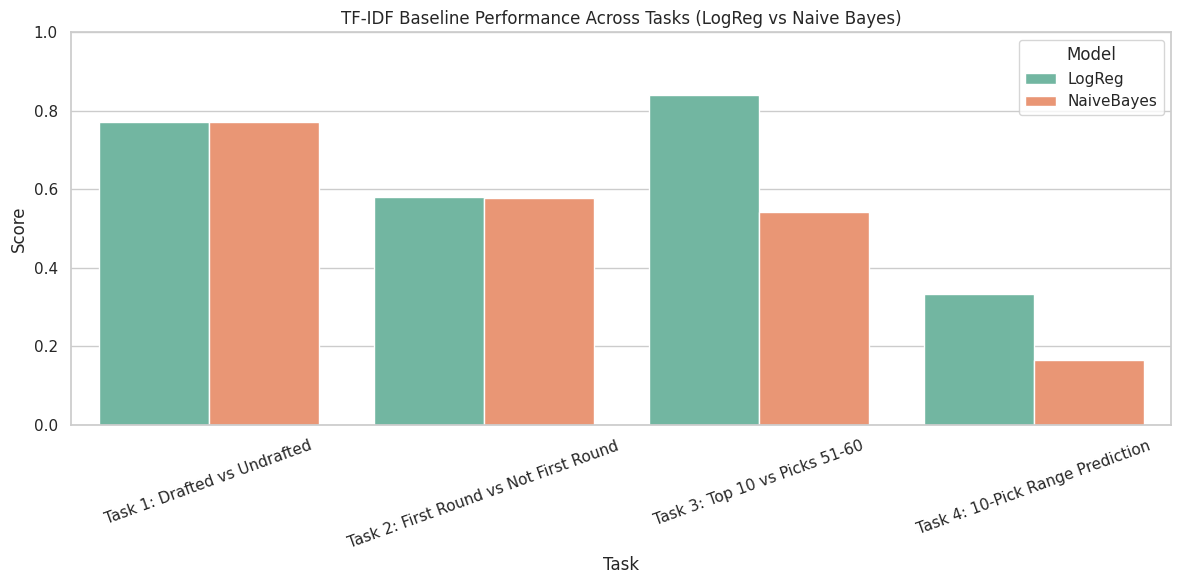

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

comparison_df_sorted = comparison_df.sort_values(by=["Task", "Model"])

plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

plot_df = comparison_df_sorted.melt(
    id_vars=["Task", "Model"],
    value_vars=["Accuracy", "F1"],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=plot_df,
    x="Task",
    y="Score",
    hue="Model",
    palette="Set2",
    ci=None
)

plt.title("TF‑IDF Baseline Performance Across Tasks (LogReg vs Naive Bayes)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

## Adding visualizations for comparison of all experiments

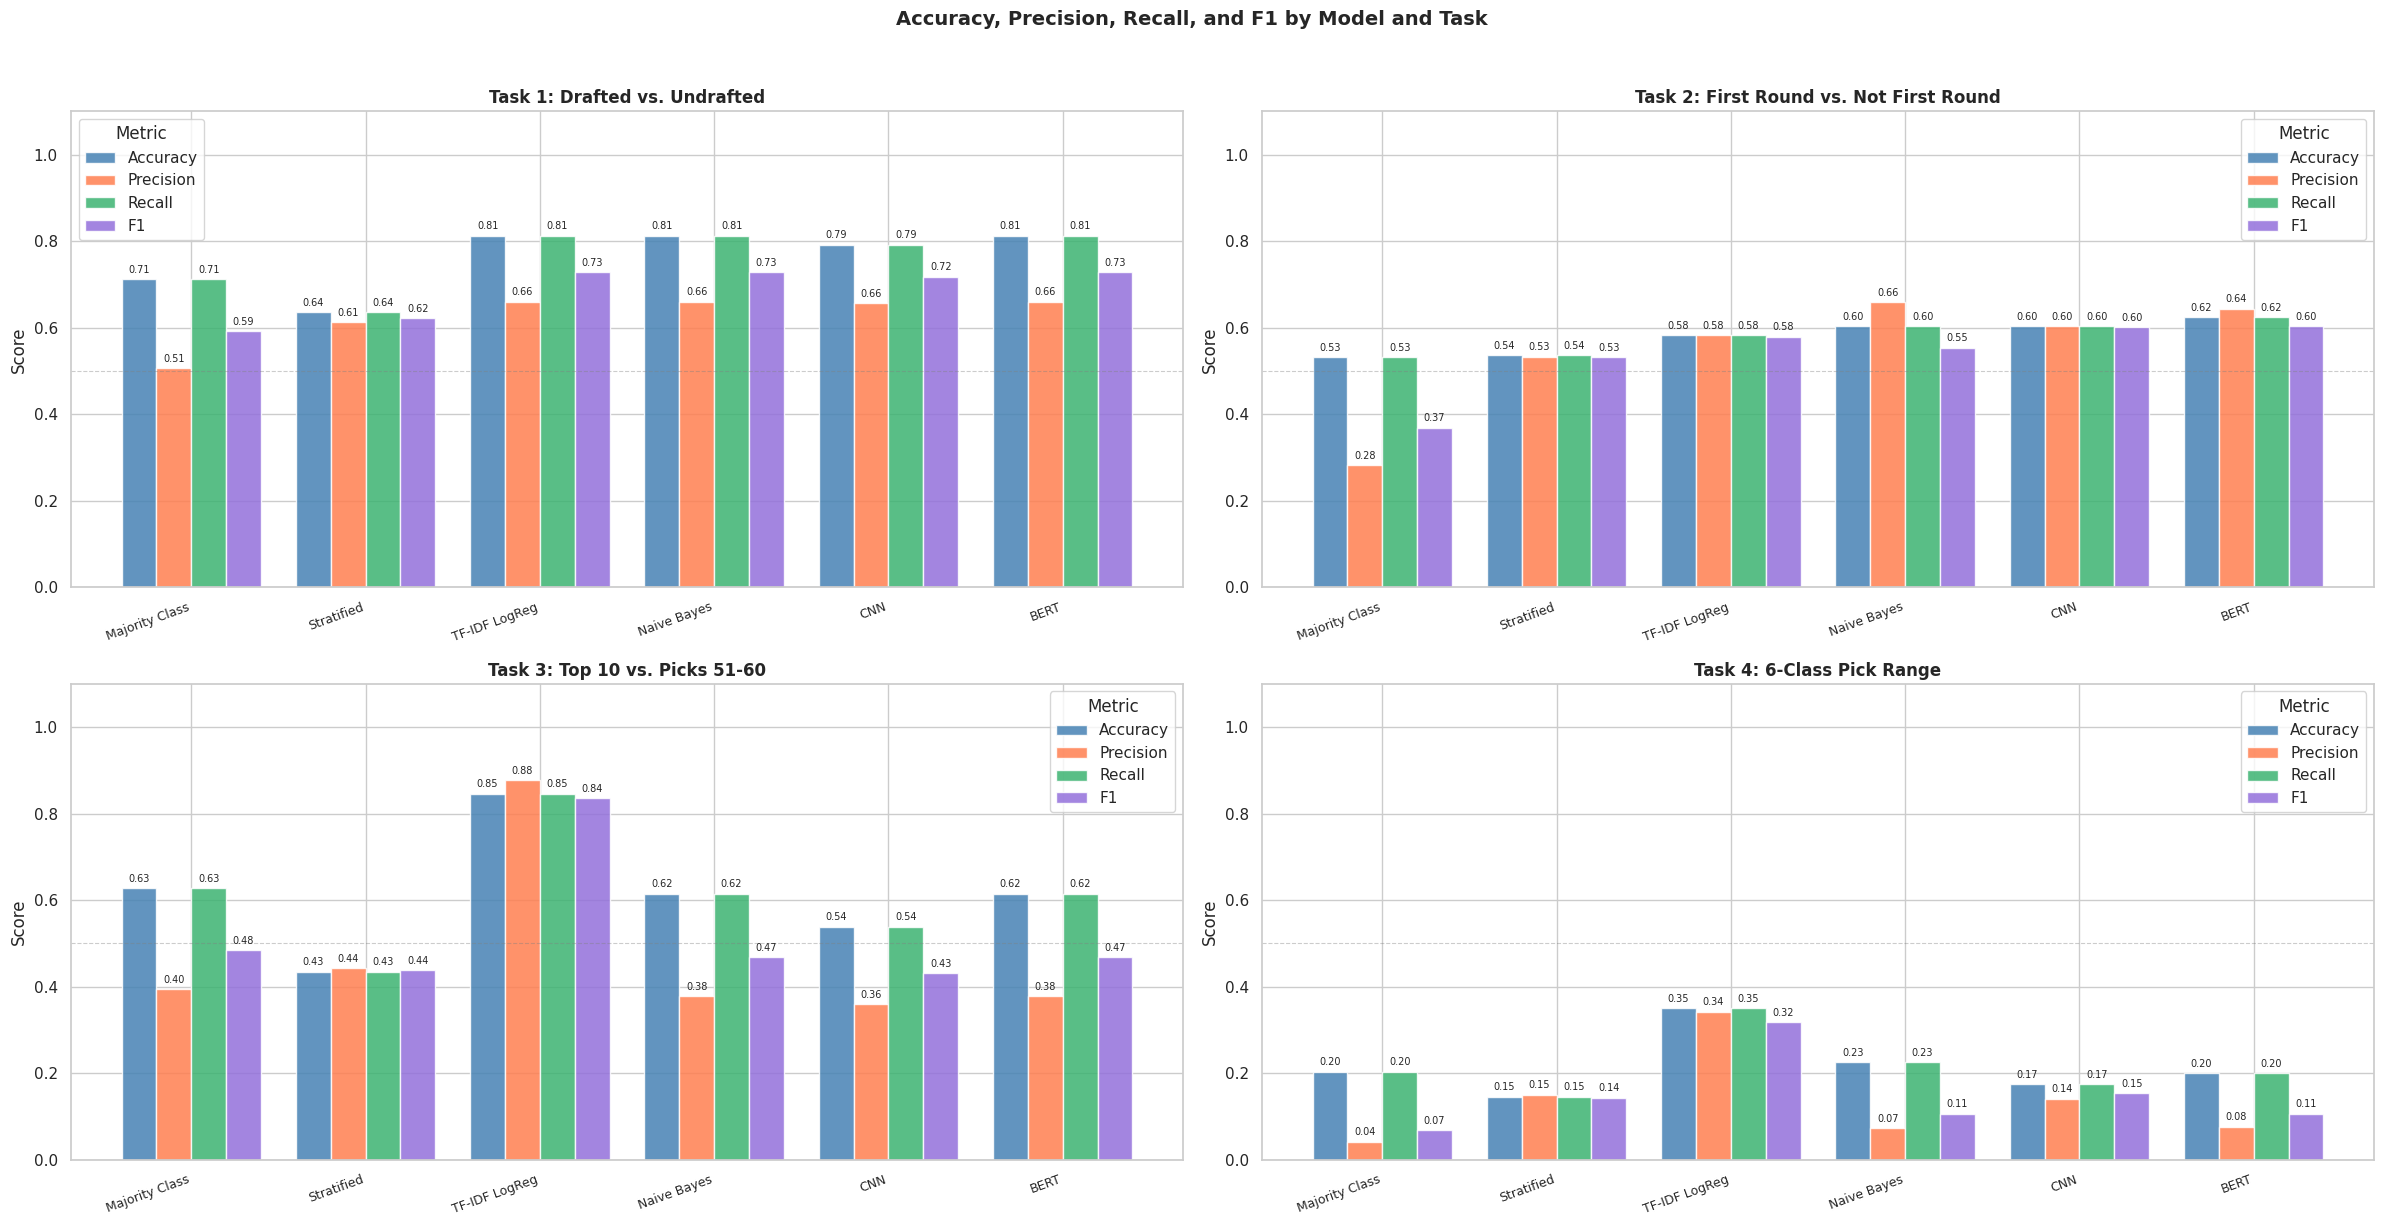

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

baseline_results = {
    'Task 1: Drafted vs. Undrafted': {
        'Majority Class':  {'Accuracy': 0.7117, 'Precision': 0.5066, 'Recall': 0.7117, 'F1': 0.5919},
        'Stratified':      {'Accuracy': 0.6355, 'Precision': 0.6125, 'Recall': 0.6355, 'F1': 0.6219},
    },
    'Task 2: First Round vs. Not First Round': {
        'Majority Class':  {'Accuracy': 0.5312, 'Precision': 0.2822, 'Recall': 0.5312, 'F1': 0.3686},
        'Stratified':      {'Accuracy': 0.5364, 'Precision': 0.5332, 'Recall': 0.5364, 'F1': 0.5323},
    },
    'Task 3: Top 10 vs. Picks 51-60': {
        'Majority Class':  {'Accuracy': 0.6273, 'Precision': 0.3950, 'Recall': 0.6273, 'F1': 0.4843},
        'Stratified':      {'Accuracy': 0.4345, 'Precision': 0.4429, 'Recall': 0.4345, 'F1': 0.4378},
    },
    'Task 4: 6-Class Pick Range': {
        'Majority Class':  {'Accuracy': 0.2036, 'Precision': 0.0416, 'Recall': 0.2036, 'F1': 0.0691},
        'Stratified':      {'Accuracy': 0.1462, 'Precision': 0.1502, 'Recall': 0.1462, 'F1': 0.1434},
    },
}

tasks_chart = {
    'Task 1: Drafted vs. Undrafted': {
        'y_test': y1_test,
        'models': {
            'Majority Class':  preds_majority_t1,
            'Stratified':      preds_stratified_t1,
            'TF-IDF LogReg':   pipes_t1['LogReg'].predict(X_test),
            'Naive Bayes':     pipes_t1['NaiveBayes'].predict(X_test),
            'CNN':             preds_cnn_t1,
            'BERT':            preds,
        }
    },
    'Task 2: First Round vs. Not First Round': {
        'y_test': y2_test,
        'models': {
            'Majority Class':  preds_majority_t2,
            'Stratified':      preds_stratified_t2,
            'TF-IDF LogReg':   pipes_t2['LogReg'].predict(X2_test),
            'Naive Bayes':     pipes_t2['NaiveBayes'].predict(X2_test),
            'CNN':             preds_cnn_t2,
            'BERT':            preds_t2,
        }
    },
    'Task 3: Top 10 vs. Picks 51-60': {
        'y_test': y3_test,
        'models': {
            'Majority Class':  preds_majority_t3,
            'Stratified':      preds_stratified_t3,
            'TF-IDF LogReg':   pipes_t3['LogReg'].predict(X3_test),
            'Naive Bayes':     pipes_t3['NaiveBayes'].predict(X3_test),
            'CNN':             preds_cnn_t3,
            'BERT':            preds_t3,
        }
    },
    'Task 4: 6-Class Pick Range': {
        'y_test': y4_test,
        'models': {
            'Majority Class':  preds_majority_t4,
            'Stratified':      preds_stratified_t4,
            'TF-IDF LogReg':   pipes_t4['LogReg'].predict(X4_test),
            'Naive Bayes':     pipes_t4['NaiveBayes'].predict(X4_test),
            'CNN':             preds_cnn_t4,
            'BERT':            preds_t4,
        }
    },
}

def get_metrics(y_true, y_pred, task_name=None, model_name=None):
    # Uses hardcoded cross-validated values for baselines
    if model_name in ('Majority Class', 'Stratified') and task_name in baseline_results:
        return baseline_results[task_name][model_name]
    avg = 'weighted'
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average=avg, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, average=avg, zero_division=0),
        'F1':        f1_score(y_true, y_pred, average=avg, zero_division=0),
    }

fig, axes = plt.subplots(2, 2, figsize=(24, 12))
axes = axes.flatten()

model_names = ['Majority Class', 'Stratified', 'TF-IDF LogReg',
               'Naive Bayes', 'CNN', 'BERT']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

x = np.arange(len(model_names))
width = 0.2

for i, (task_name, task_data) in enumerate(tasks_chart.items()):
    ax = axes[i]
    y_test = task_data['y_test']

    for j, metric in enumerate(metric_names):
        scores = [
            get_metrics(y_test, task_data['models'][m], task_name=task_name, model_name=m)[metric]
            for m in model_names
        ]

        bars = ax.bar(x + j * width, scores, width,
                      label=metric, color=colors[j], alpha=0.85)

        for bar, score in zip(bars, scores):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{score:.2f}',
                ha='center', va='bottom', fontsize=7
            )

    ax.set_title(task_name, fontsize=12, fontweight='bold')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(model_names, fontsize=9, rotation=20, ha='right')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.1)
    ax.legend(title='Metric')
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

plt.suptitle('Accuracy, Precision, Recall, and F1 by Model and Task',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/metrics_comparison.png", dpi=150, bbox_inches='tight')
plt.show()